# 数据预处理


首先对数据进行预处理



------------数据预处理------------

1. 预处理手写数据集
项目中共有 270 个数据文件夹

2. 数据集统计
总文件夹数: 270
分布类型数: 15
手写样本文件夹数: 173
非手写样本文件夹数: 97
总文件数: 563

各分布详细统计:
  ('二项分布', False): 17 个文件
  ('二项分布', True): 33 个文件
  ('伯努利分布', False): 13 个文件
  ('伯努利分布', True): 10 个文件
  ('伽马分布', False): 5 个文件
  ('伽马分布', True): 2 个文件
  ('卡方分布', False): 2 个文件
  ('卡方分布', True): 9 个文件
  ('均匀分布', True): 9 个文件
  ('帕累托分布', True): 2 个文件
  ('幂律分布', False): 2 个文件
  ('指数分布', False): 5 个文件
  ('指数分布', True): 14 个文件
  ('未知分布_14', True): 4 个文件
  ('未知分布_15', True): 4 个文件
  ('正态分布', False): 76 个文件
  ('正态分布', True): 156 个文件
  ('泊松分布', False): 72 个文件
  ('泊松分布', True): 97 个文件
  ('莱斯分布', False): 2 个文件
  ('贝塔分布', False): 6 个文件
  ('贝塔分布', True): 9 个文件
  ('高斯混合模型', False): 11 个文件
  ('高斯混合模型', True): 3 个文件

3. 数据分布可视化图表
图表已保存到: data_distribution_plots.png


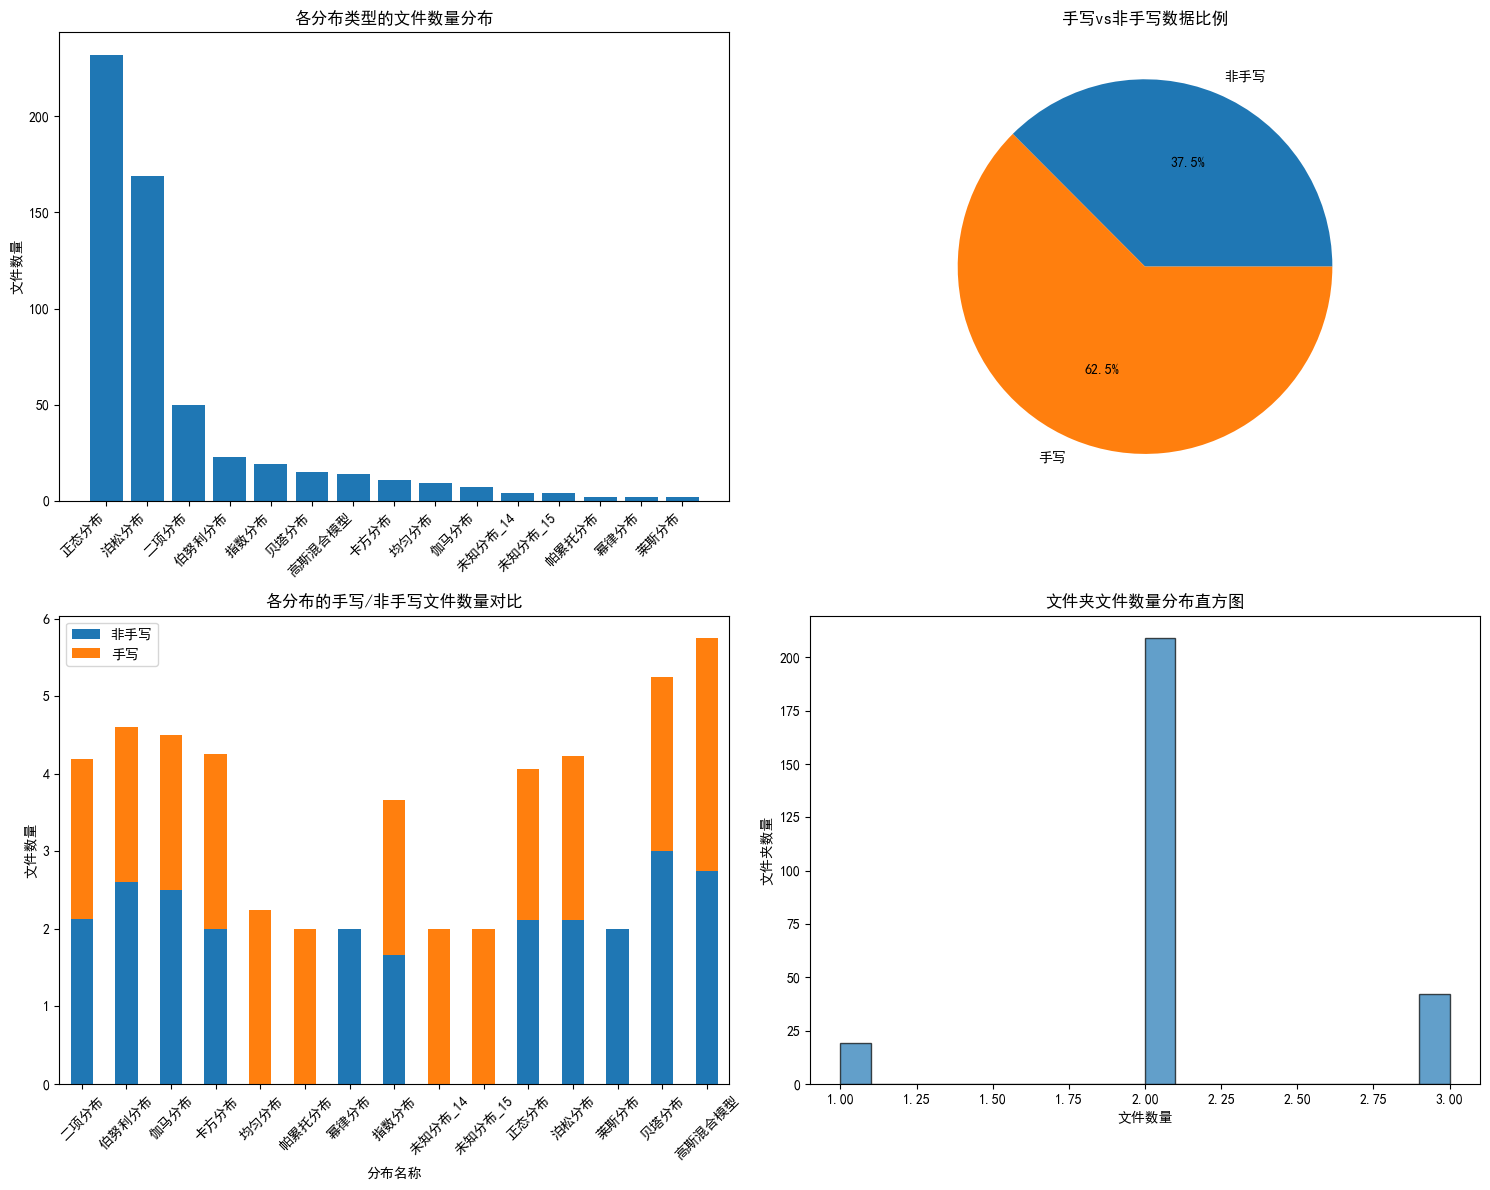


4. 保存数据信息
数据信息已保存到: data_info.txt

5. 重新组织数据到 ./processed_data
已处理: 1_1 -> processed_data\伯努利分布\非手写 (复制了1个文件)
已处理: 1_2 -> processed_data\伯努利分布\非手写 (复制了1个文件)
已处理: 1_3 -> processed_data\伯努利分布\非手写 (复制了1个文件)
已处理: 1_4 -> processed_data\伯努利分布\非手写 (复制了1个文件)
已处理: 1_5 -> processed_data\伯努利分布\非手写 (复制了1个文件)
已处理: 1_10y -> processed_data\伯努利分布\手写 (复制了1个文件)
已处理: 1_6y -> processed_data\伯努利分布\手写 (复制了1个文件)
已处理: 1_7y -> processed_data\伯努利分布\手写 (复制了1个文件)
已处理: 1_8y -> processed_data\伯努利分布\手写 (复制了1个文件)
已处理: 1_9y -> processed_data\伯努利分布\手写 (复制了1个文件)
已处理: 2_11 -> processed_data\贝塔分布\非手写 (复制了1个文件)
已处理: 2_12 -> processed_data\贝塔分布\非手写 (复制了1个文件)
已处理: 2_13y -> processed_data\贝塔分布\手写 (复制了1个文件)
已处理: 2_14y -> processed_data\贝塔分布\手写 (复制了1个文件)
已处理: 2_217y -> processed_data\贝塔分布\手写 (复制了1个文件)
已处理: 2_265y -> processed_data\贝塔分布\手写 (复制了1个文件)
已处理: 3_15 -> processed_data\二项分布\非手写 (复制了1个文件)
已处理: 3_16 -> processed_data\二项分布\非手写 (复制了1个文件)
已处理: 3_17 -> processed_data\二项分布\非手写 (复制了1个文件)
已处理: 3_18 -> processed_data\二项分布\非手写 (复制

In [5]:
import os
import shutil
import re
from pathlib import Path
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 定义分布映射表
distribution_map = {
    1: '伯努利分布',
    2: '贝塔分布', 
    3: '二项分布',
    4: '伽马分布',
    5: '高斯混合模型',
    6: '均匀分布',
    7: '卡方分布',
    8: '莱斯分布',
    9: '幂律分布',
    10: '帕累托分布',
    11: '泊松分布',
    12: '正态分布',
    13: '指数分布'
}

def parse_folder_name(folder_name):
    """
    解析文件夹名称，提取分布类型和是否为手写
    
    Args:
        folder_name: 文件夹名称，如 '11_90y'
        
    Returns:
        tuple: (分布编号, 是否手写, 分布名称)
    """
    # 使用正则表达式匹配文件夹名称模式
    pattern = r'(\d+)_(\d+)([yn]?)'
    match = re.match(pattern, folder_name)
    
    if match:
        dist_num = int(match.group(1))
        is_handwritten = match.group(3) == 'y' if match.group(3) else False
        dist_name = distribution_map.get(dist_num, f'未知分布_{dist_num}')
        return dist_num, is_handwritten, dist_name
    else:
        return None, None, None

def scan_data_structure(data_root_path):
    """
    扫描数据结构，统计各类文件夹信息
    
    Args:
        data_root_path: 数据根目录路径
        
    Returns:
        pd.DataFrame: 包含文件夹信息的数据框
    """
    folder_info = []
    data_root_path = Path(data_root_path)
    
    if not data_root_path.exists():
        print(f"错误：数据路径 {data_root_path} 不存在")
        return pd.DataFrame()
    
    # 遍历所有子文件夹
    for folder_path in data_root_path.iterdir():
        if folder_path.is_dir():
            folder_name = folder_path.name
            dist_num, is_handwritten, dist_name = parse_folder_name(folder_name)
            
            # 只处理能正确解析的文件夹
            if dist_num is not None:
                # 统计文件夹内文件数量
                file_count = len([f for f in folder_path.iterdir() if f.is_file()])
                
                folder_info.append({
                    '文件夹名称': folder_name,
                    '分布编号': dist_num,
                    '分布名称': dist_name,
                    '是否手写': is_handwritten,
                    '文件数量': file_count,
                    '文件夹路径': str(folder_path)
                })
    
    df = pd.DataFrame(folder_info)
    return df.sort_values(['分布编号', '是否手写']) if not df.empty else df

def generate_data_summary(df):
    """
    生成数据摘要统计
    
    Args:
        df: 文件夹信息数据框
        
    Returns:
        dict: 统计摘要
    """
    summary = {
        '总文件夹数': len(df),
        '分布类型数': df['分布编号'].nunique(),
        '手写样本文件夹数': len(df[df['是否手写'] == True]),
        '非手写样本文件夹数': len(df[df['是否手写'] == False]),
        '总文件数': df['文件数量'].sum(),
        '各分布统计': df.groupby(['分布名称', '是否手写'])['文件数量'].sum().to_dict()
    }
    return summary

def visualize_data_distribution(df, save_path='data_distribution_plots.png'):
    """
    可视化数据分布情况
    
    Args:
        df: 文件夹信息数据框
        save_path: 保存图片的路径
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. 各分布类型的文件数量
    dist_counts = df.groupby('分布名称')['文件数量'].sum().sort_values(ascending=False)
    axes[0, 0].bar(range(len(dist_counts)), dist_counts.values)
    axes[0, 0].set_title('各分布类型的文件数量分布')
    axes[0, 0].set_xticks(range(len(dist_counts)))
    axes[0, 0].set_xticklabels(dist_counts.index, rotation=45, ha='right')
    axes[0, 0].set_ylabel('文件数量')
    
    # 2. 手写vs非手写对比
    handwriting_counts = df.groupby('是否手写')['文件数量'].sum()
    labels = ['非手写', '手写']
    axes[0, 1].pie(handwriting_counts.values, labels=labels, autopct='%1.1f%%')
    axes[0, 1].set_title('手写vs非手写数据比例')
    
    # 3. 各分布的手写/非手写详细对比
    pivot_table = df.pivot_table(values='文件数量', index='分布名称', columns='是否手写', fill_value=0)
    pivot_table.plot(kind='bar', ax=axes[1, 0], stacked=True)
    axes[1, 0].set_title('各分布的手写/非手写文件数量对比')
    axes[1, 0].set_ylabel('文件数量')
    axes[1, 0].legend(['非手写', '手写'])
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # 4. 文件数量分布直方图
    axes[1, 1].hist(df['文件数量'], bins=20, edgecolor='black', alpha=0.7)
    axes[1, 1].set_title('文件夹文件数量分布直方图')
    axes[1, 1].set_xlabel('文件数量')
    axes[1, 1].set_ylabel('文件夹数量')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"图表已保存到: {save_path}")
    plt.show()

def organize_data(df, output_path):
    """
    重新组织数据结构，按分布类型和手写/非手写分类
    
    Args:
        df: 文件夹信息数据框
        output_path: 输出路径
    """
    output_path = Path(output_path)
    
    # 如果输出目录存在，先删除
    if output_path.exists():
        shutil.rmtree(output_path)
    
    # 创建输出目录
    output_path.mkdir(exist_ok=True)
    
    copied_files_count = 0
    
    # 创建新的目录结构
    for _, row in df.iterrows():
        dist_name = row['分布名称']
        is_handwritten = row['是否手写']
        
        # 创建目标目录
        target_dir = output_path / dist_name / ('手写' if is_handwritten else '非手写')
        target_dir.mkdir(parents=True, exist_ok=True)
        
        # 复制文件
        source_dir = Path(row['文件夹路径'])
        folder_copied_count = 0
        
        for file_path in source_dir.iterdir():
            if file_path.is_file():
                # 检查是否为图像文件
                image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.gif'}
                if file_path.suffix.lower() in image_extensions:
                    target_file = target_dir / file_path.name
                    try:
                        shutil.copy2(file_path, target_file)
                        folder_copied_count += 1
                        copied_files_count += 1
                    except Exception as e:
                        print(f"复制文件失败 {file_path}: {e}")
        
        print(f"已处理: {row['文件夹名称']} -> {target_dir} (复制了{folder_copied_count}个文件)")
    
    print(f"\n数据重组完成！总共复制了 {copied_files_count} 个图像文件")
    return copied_files_count

def save_data_info(df, summary, save_path='data_info.txt'):
    """
    保存数据信息到文本文件
    
    Args:
        df: 数据框
        summary: 统计摘要
        save_path: 保存路径
    """
    with open(save_path, 'w', encoding='utf-8') as f:
        f.write("=" * 50 + "\n")
        f.write("数据预处理报告\n")
        f.write("=" * 50 + "\n\n")
        
        f.write("1. 数据摘要统计:\n")
        for key, value in summary.items():
            if key != '各分布统计':
                f.write(f"   {key}: {value}\n")
        
        f.write("\n2. 各分布详细统计:\n")
        for dist_type, count in summary['各分布统计'].items():
            f.write(f"   {dist_type}: {count} 个文件\n")
        
        f.write("\n3. 详细文件夹信息:\n")
        f.write(df.to_string(index=False))
        
        f.write("\n\n4. 分布映射表:\n")
        for num, name in distribution_map.items():
            f.write(f"   {num}: {name}\n")
    
    print(f"数据信息已保存到: {save_path}")

# 主要执行代码
print("=" * 50)
print("------------数据预处理------------")
print("=" * 50)

# 请修改为您的实际数据路径
data_root_path = "../data/data1/"  # 请替换为实际路径
output_path = "./processed_data"  # 处理后数据的输出路径（当前目录下）

# 1. 扫描数据结构
print("\n1. 预处理手写数据集")
df = scan_data_structure(data_root_path)

if not df.empty:
    print(f"项目中共有 {len(df)} 个数据文件夹")
    
    # 2. 生成统计摘要
    print("\n2. 数据集统计")
    summary = generate_data_summary(df)
    for key, value in summary.items():
        if key != '各分布统计':
            print(f"{key}: {value}")
    
    print("\n各分布详细统计:")
    for dist_type, count in summary['各分布统计'].items():
        print(f"  {dist_type}: {count} 个文件")
    
    # 3. 可视化数据分布
    print("\n3. 数据分布可视化图表")
    visualize_data_distribution(df)
    
    # 4. 保存数据信息
    print("\n4. 保存数据信息")
    save_data_info(df, summary, 'data_info.txt')
    
    # 5. 重新组织数据（必须执行）
    print(f"\n5. 重新组织数据到 {output_path}")
    copied_count = organize_data(df, output_path)
    
    if copied_count > 0:
        print(f"\n 数据重组成功完成！")
        print(f" processed_data 文件夹已创建在当前目录")
        print(f" 总共处理了 {copied_count} 个图像文件")
        
        # 验证生成的文件夹结构
        print(f"\n6. 验证生成的文件夹结构:")
        output_path_obj = Path(output_path)
        for dist_folder in output_path_obj.iterdir():
            if dist_folder.is_dir():
                print(f"  📁 {dist_folder.name}/")
                for type_folder in dist_folder.iterdir():
                    if type_folder.is_dir():
                        file_count = len([f for f in type_folder.iterdir() if f.is_file()])
                        print(f"    📁 {type_folder.name}/ ({file_count} 个文件)")
    else:
        print("没有找到图像文件进行复制")
    
    # 6. 保存处理后的DataFrame
    df.to_csv('folder_info.csv', index=False, encoding='utf-8')
    print(f"\n文件夹信息已保存到: folder_info.csv")
    
else:
    print("未找到有效的数据文件夹，请检查数据路径是否正确")
    print("确保数据文件夹命名格式为: 数字_数字[y/n]")
    print("例如: 11_90y, 12_80n, 1_100")


# 特征提取



开始图像特征提取
输出目录: c:\Users\26402\Desktop\模式识别与机器学习\课程实践+2022303210+刘力豪\src\..\outputs\part2

1. 加载图像数据
加载 二项分布 - 手写: 13 张图像
加载 二项分布 - 非手写: 5 张图像
加载 伯努利分布 - 手写: 5 张图像
加载 伯努利分布 - 非手写: 4 张图像
加载 伽马分布 - 手写: 1 张图像
加载 伽马分布 - 非手写: 2 张图像
加载 卡方分布 - 手写: 4 张图像
加载 卡方分布 - 非手写: 1 张图像
加载 均匀分布 - 手写: 4 张图像
加载 帕累托分布 - 手写: 1 张图像
加载 幂律分布 - 非手写: 1 张图像
加载 指数分布 - 手写: 7 张图像
加载 指数分布 - 非手写: 2 张图像
加载 未知分布_14 - 手写: 2 张图像
加载 未知分布_15 - 手写: 2 张图像
加载 正态分布 - 手写: 42 张图像
加载 正态分布 - 非手写: 21 张图像
加载 泊松分布 - 手写: 29 张图像
加载 泊松分布 - 非手写: 11 张图像
加载 莱斯分布 - 非手写: 1 张图像
加载 贝塔分布 - 手写: 4 张图像
加载 贝塔分布 - 非手写: 2 张图像
加载 高斯混合模型 - 手写: 1 张图像
加载 高斯混合模型 - 非手写: 3 张图像
总共加载 168 张图像
图像形状: (128, 128, 3)
分布类型: ['二项分布' '伯努利分布' '伽马分布' '卡方分布' '均匀分布' '帕累托分布' '幂律分布' '指数分布' '未知分布_14'
 '未知分布_15' '正态分布' '泊松分布' '莱斯分布' '贝塔分布' '高斯混合模型']

2. 提取传统图像特征
传统特征维度: (168, 34124)

3. 训练自编码器
Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - loss: 0.1070 - val_loss: 0.0552
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0492 - val_loss: 0.0312
Epoch 3/20
5/5 ━━━━━━━

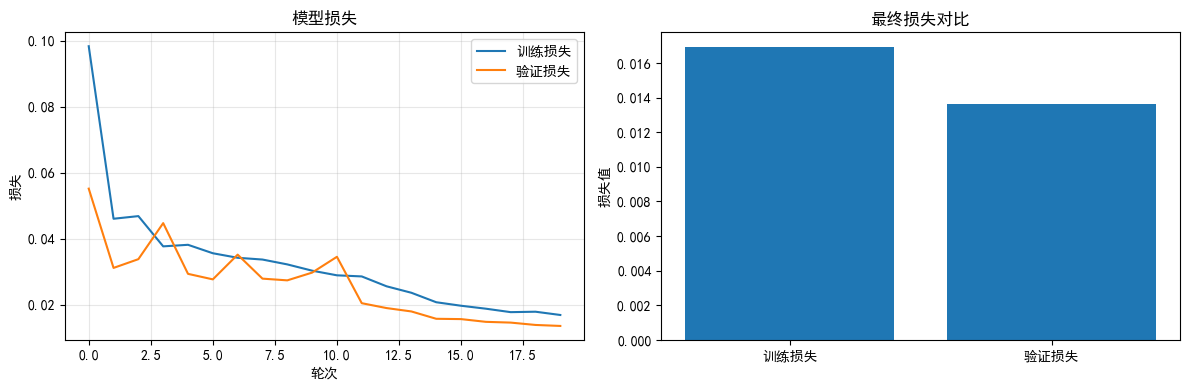

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
自编码器特征维度: (168, 2048)

4. 合并特征
合并后特征维度: (168, 36172)
特征分析图表已保存到: ..\outputs\part2\feature_analysis.png


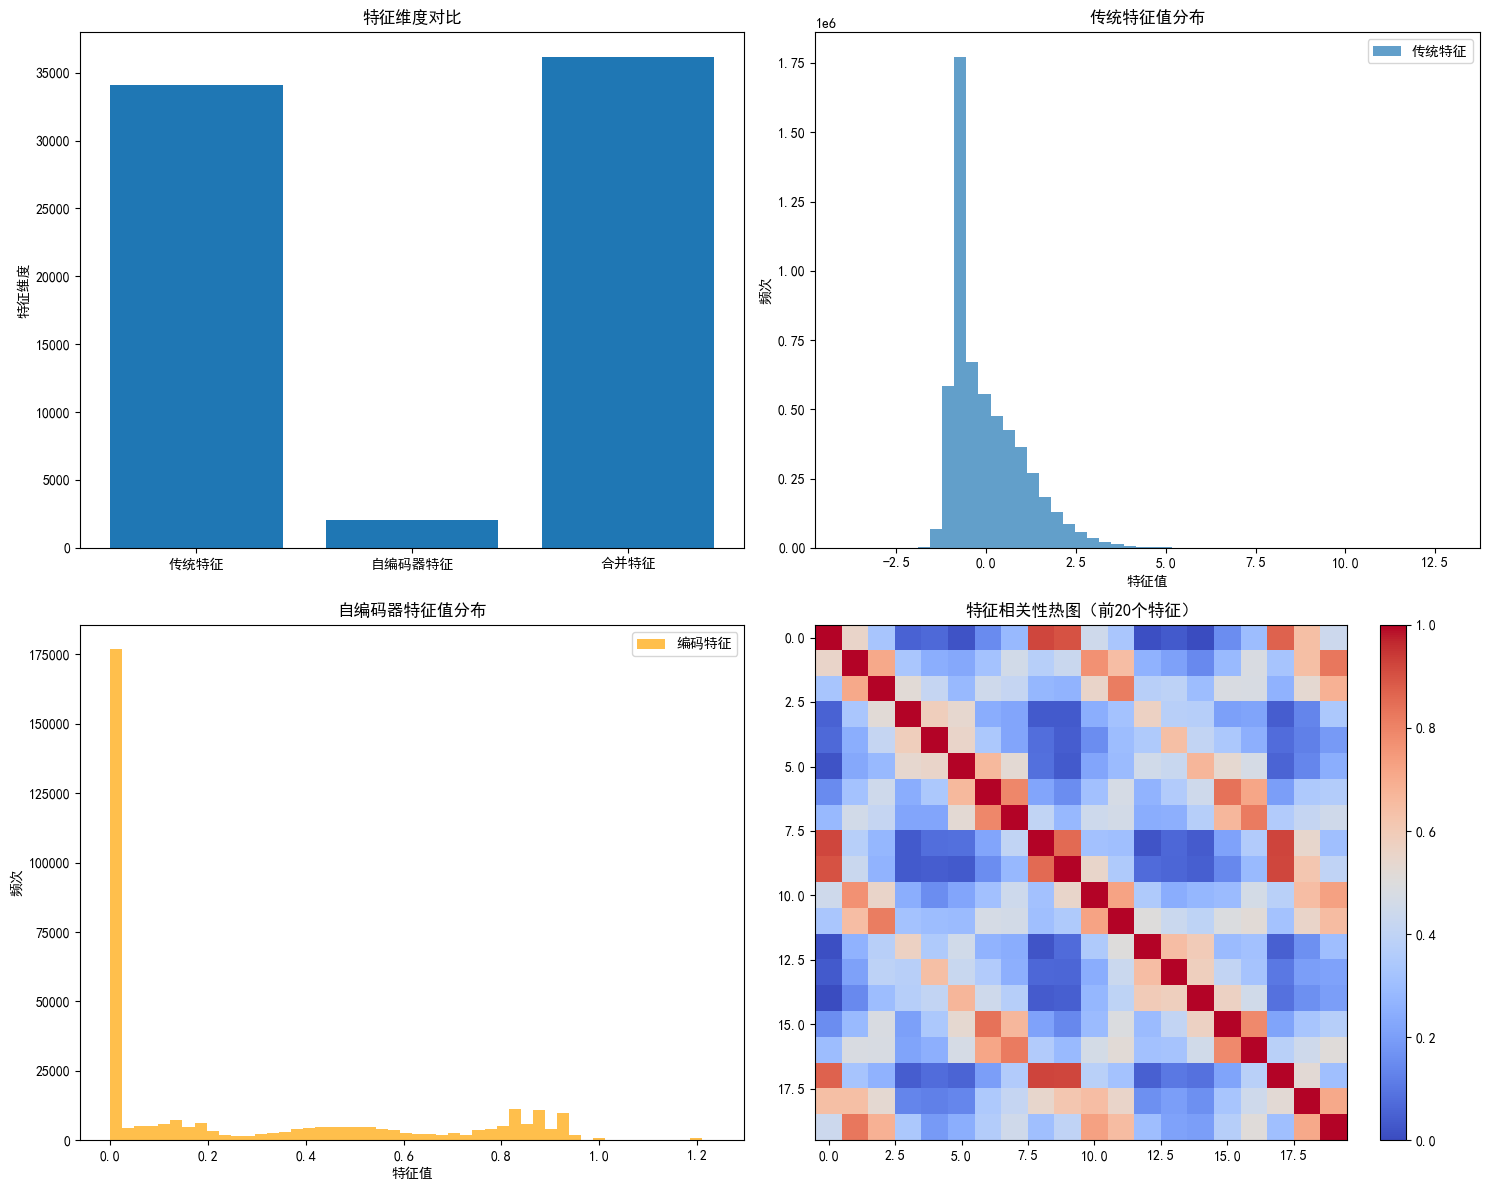


5. 应用降维算法
PCA解释方差比: [0.1723647  0.06497137]
PCA解释方差比: [0.1723647  0.06497137 0.02400199]

6. 生成可视化图表
图表已保存到: ..\outputs\part2\PCA降维结果.png


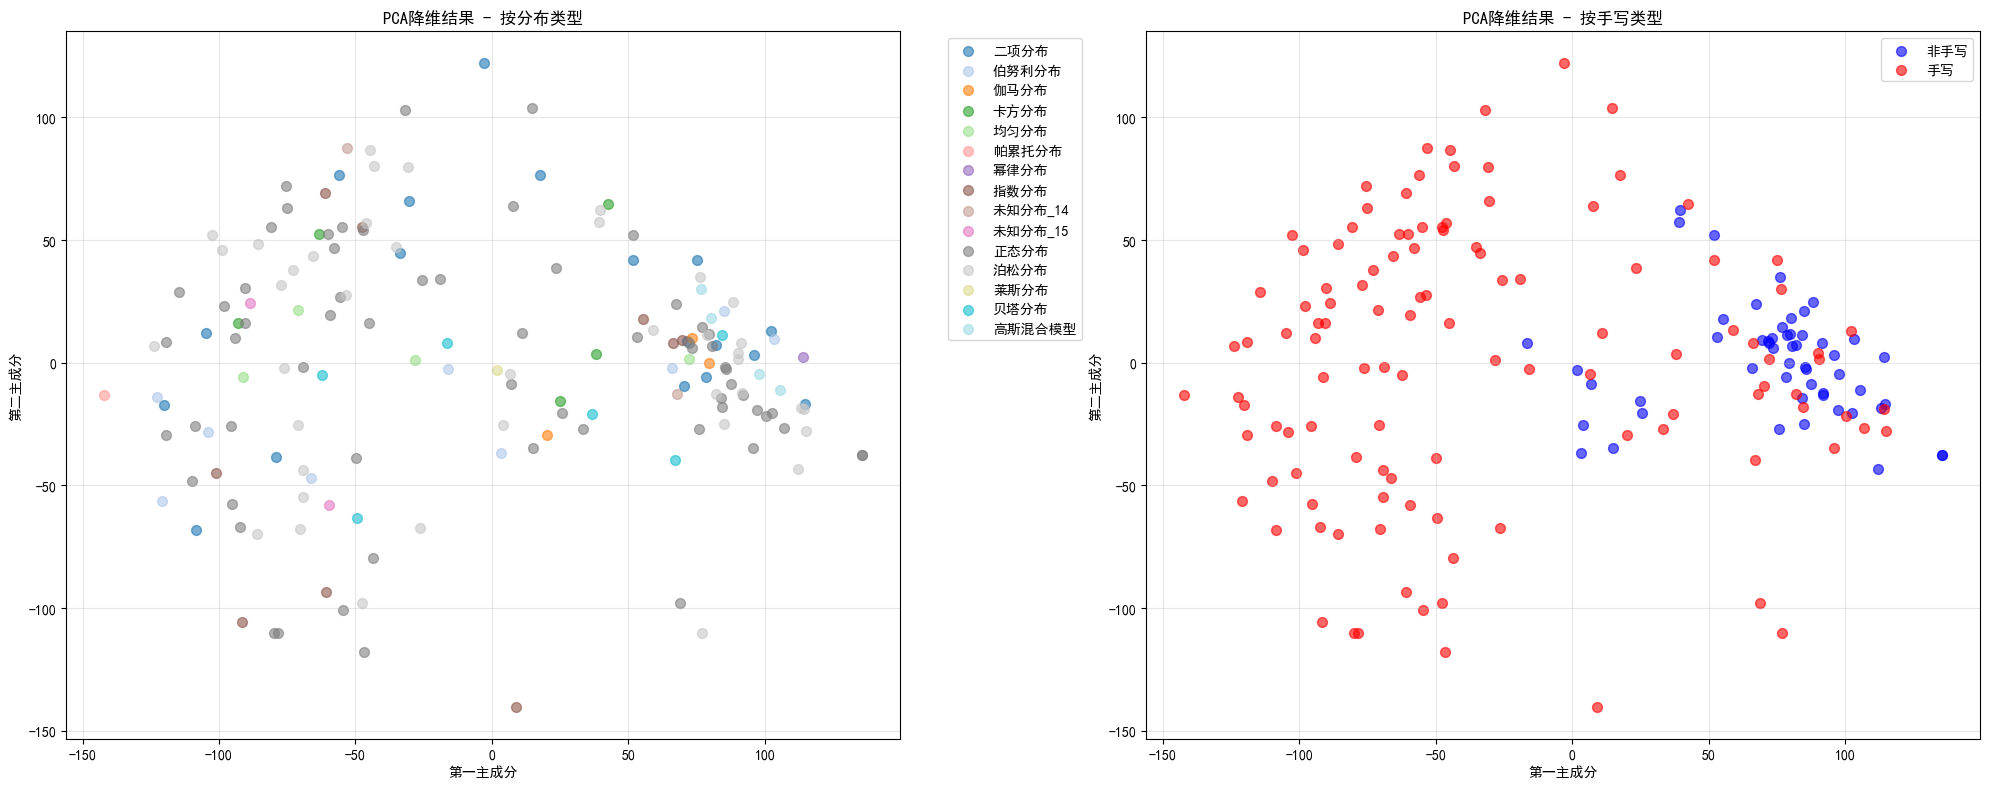

图表已保存到: ..\outputs\part2\LDA降维结果.png


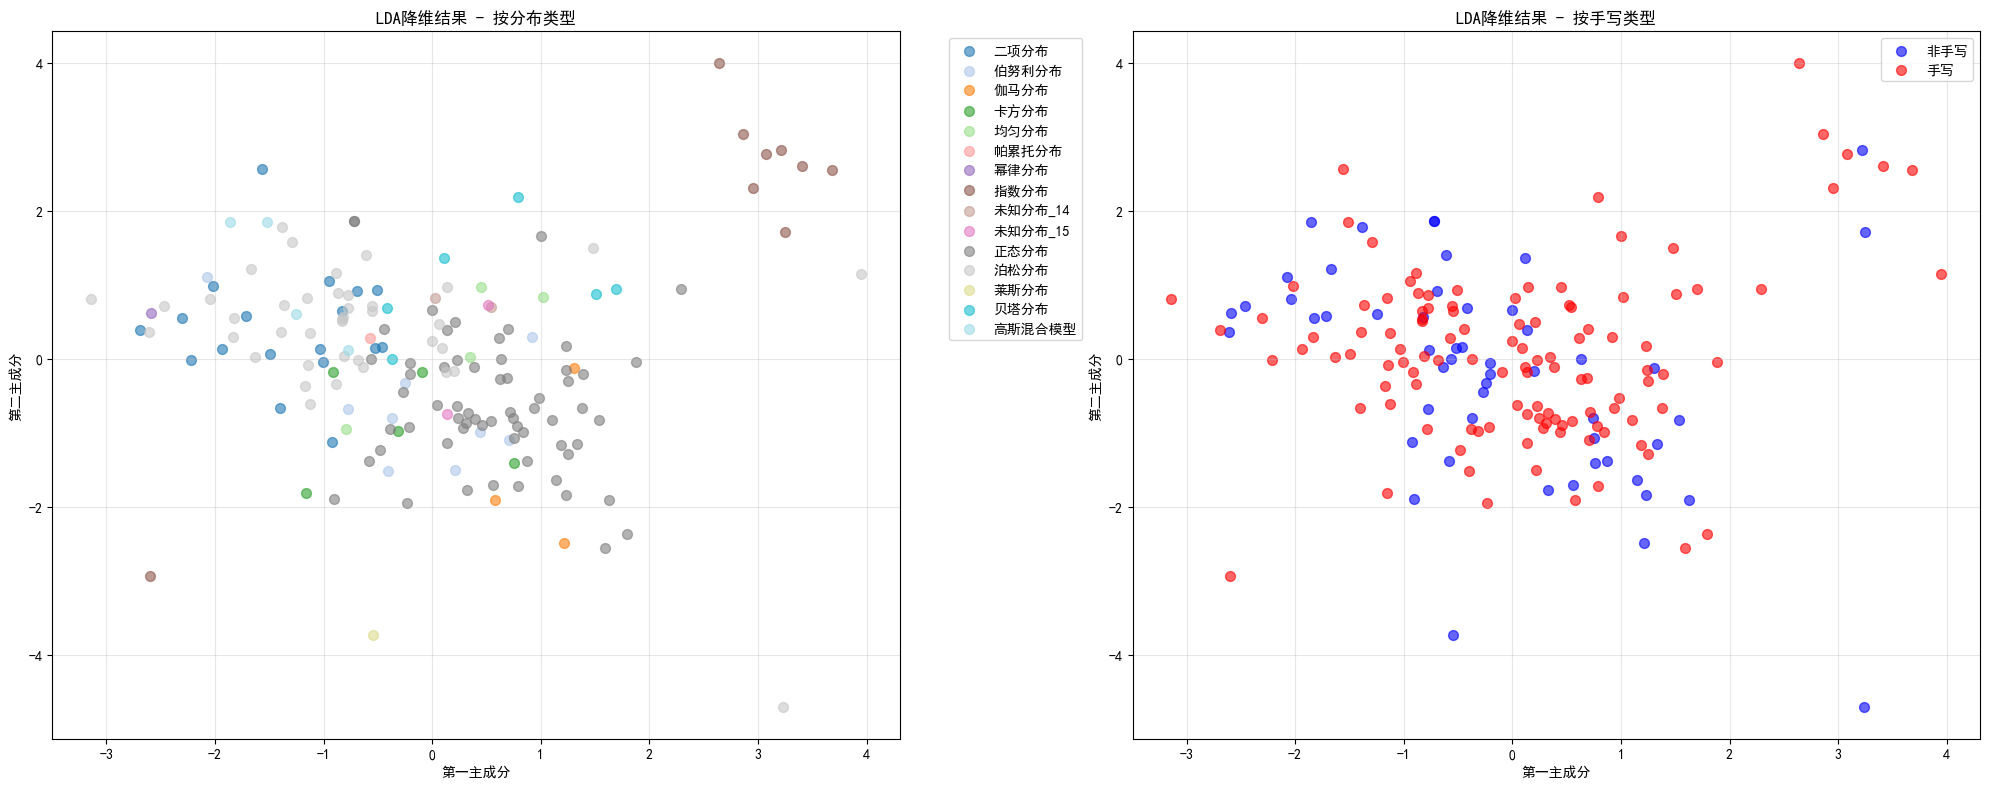

图表已保存到: ..\outputs\part2\t_SNE降维结果.png


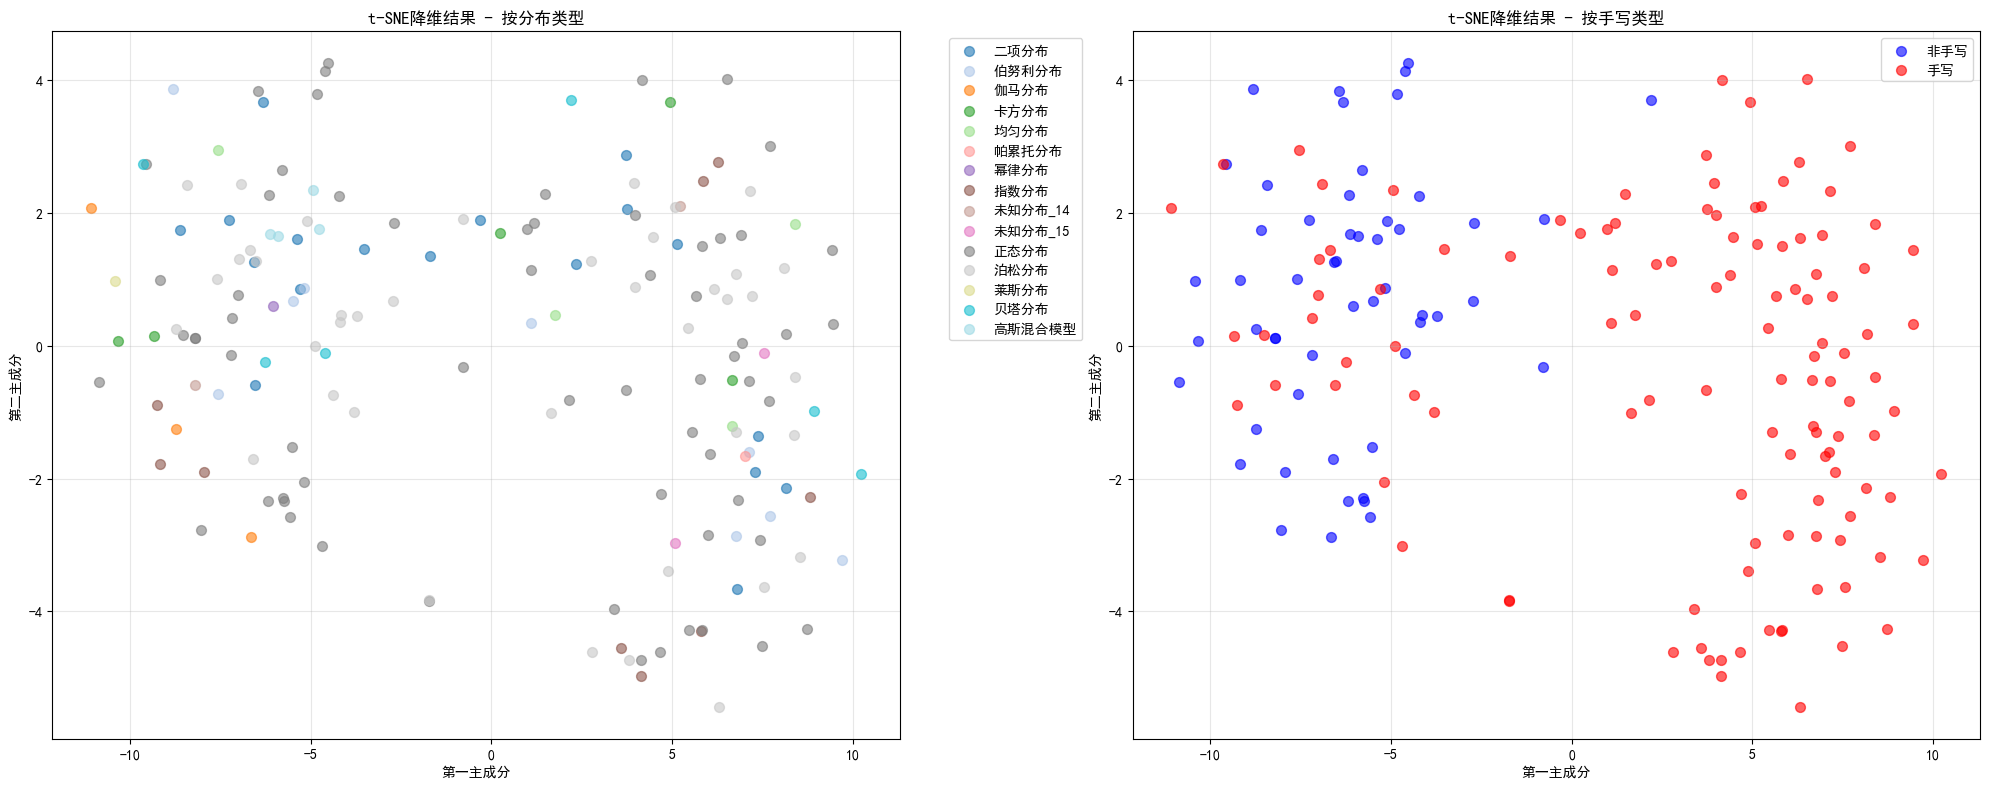

3D可视化图表已保存到: ..\outputs\part2\PCA_3D_visualization.png


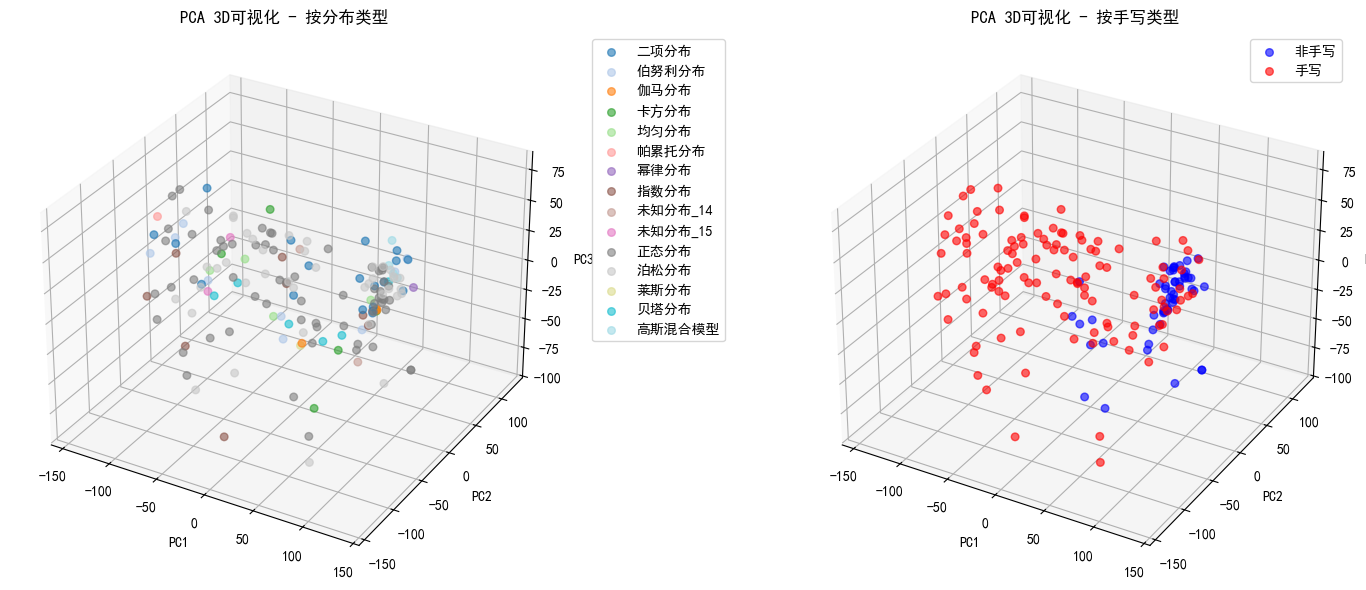


7. 保存特征和模型

8. 生成分析报告
分析报告已保存到: ..\outputs\part2\feature_extraction_report.txt

特征提取和降维完成！
所有文件已保存到: c:\Users\26402\Desktop\模式识别与机器学习\课程实践+2022303210+刘力豪\src\..\outputs\part2

生成的文件包括:
 可视化图表:
  - PCA降维结果.png
  - LDA降维结果.png
  - t_SNE降维结果.png
  - PCA_3D_visualization.png
  - training_history.png
  - feature_analysis.png

 特征数据:
  - traditional_features.npy
  - encoded_features.npy
  - combined_features.npy
  - features_pca_2d.npy
  - features_pca_3d.npy
  - features_lda_2d.npy
  - features_tsne_2d.npy

 模型文件:
  - autoencoder_model.h5
  - encoder_model.h5
  - pca_reducer.pkl
  - lda_reducer.pkl
  - scaler.pkl

 报告文件:
  - feature_extraction_report.txt


In [6]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, Reshape
from tensorflow.keras.optimizers import Adam
import seaborn as sns
from sklearn.manifold import TSNE
import os
import pickle
from pathlib import Path

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建输出目录
output_dir = Path("../outputs/part2/")
output_dir.mkdir(exist_ok=True, parents=True)

class ImageFeatureExtractor:
    def __init__(self, image_size=(128, 128)):
        """
        初始化图像特征提取器
        
        Args:
            image_size: 图像统一尺寸
        """
        self.image_size = image_size
        self.scaler = StandardScaler()
        
    def load_images_from_folder(self, folder_path, max_images=None):
        """
        从文件夹加载图像
        
        Args:
            folder_path: 文件夹路径
            max_images: 最大加载图像数量
            
        Returns:
            list: 图像数组列表
        """
        images = []
        folder_path = Path(folder_path)
        
        # 支持的图像格式
        image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
        
        image_files = [f for f in folder_path.iterdir() 
                      if f.suffix.lower() in image_extensions]
        
        if max_images:
            image_files = image_files[:max_images]
        
        for img_path in image_files:
            try:
                # 使用PIL加载图像
                img = Image.open(img_path)
                # 转换为RGB格式
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                # 调整大小
                img = img.resize(self.image_size)
                # 转换为numpy数组
                img_array = np.array(img)
                images.append(img_array)
            except Exception as e:
                print(f"加载图像失败 {img_path}: {e}")
        
        return np.array(images)
    
    def extract_traditional_features(self, images):
        """
        提取传统图像特征（HOG、LBP、颜色直方图等）
        
        Args:
            images: 图像数组
            
        Returns:
            np.array: 特征矩阵
        """
        features = []
        
        for img in images:
            img_features = []
            
            # 转换为灰度图
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            
            # 1. HOG特征
            hog = cv2.HOGDescriptor()
            hog_features = hog.compute(gray)
            if hog_features is not None:
                img_features.extend(hog_features.flatten())
            
            # 2. 颜色直方图特征
            hist_r = cv2.calcHist([img], [0], None, [32], [0, 256])
            hist_g = cv2.calcHist([img], [1], None, [32], [0, 256])
            hist_b = cv2.calcHist([img], [2], None, [32], [0, 256])
            img_features.extend(hist_r.flatten())
            img_features.extend(hist_g.flatten())
            img_features.extend(hist_b.flatten())
            
            # 3. 纹理特征（简化版LBP）
            # 计算局部二值模式的简化版本
            texture_features = self._extract_texture_features(gray)
            img_features.extend(texture_features)
            
            # 4. 形状特征
            shape_features = self._extract_shape_features(gray)
            img_features.extend(shape_features)
            
            features.append(img_features)
        
        return np.array(features)
    
    def _extract_texture_features(self, gray_img):
        """提取纹理特征"""
        # 计算灰度共生矩阵的简化特征
        # 这里使用简化的方法计算纹理特征
        
        # 计算梯度
        grad_x = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)
        
        # 梯度幅值和方向
        magnitude = np.sqrt(grad_x**2 + grad_y**2)
        
        # 统计特征
        texture_features = [
            np.mean(magnitude),
            np.std(magnitude),
            np.mean(gray_img),
            np.std(gray_img)
        ]
        
        return texture_features
    
    def _extract_shape_features(self, gray_img):
        """提取形状特征"""
        # 边缘检测
        edges = cv2.Canny(gray_img, 50, 150)
        
        # 轮廓检测
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            # 最大轮廓
            largest_contour = max(contours, key=cv2.contourArea)
            
            # 形状特征
            area = cv2.contourArea(largest_contour)
            perimeter = cv2.arcLength(largest_contour, True)
            
            # 避免除零错误
            if perimeter > 0:
                circularity = 4 * np.pi * area / (perimeter * perimeter)
            else:
                circularity = 0
            
            # 边界框
            x, y, w, h = cv2.boundingRect(largest_contour)
            aspect_ratio = float(w) / h if h > 0 else 0
            
            shape_features = [area, perimeter, circularity, aspect_ratio]
        else:
            shape_features = [0, 0, 0, 0]
        
        return shape_features
    
    def build_autoencoder(self, input_shape):
        """
        构建自编码器模型
        
        Args:
            input_shape: 输入形状
            
        Returns:
            tuple: (自编码器模型, 编码器模型)
        """
        # 输入层
        input_img = Input(shape=input_shape)
        
        # 编码器
        x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
        x = MaxPooling2D((2, 2), padding='same')(x)
        x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
        x = MaxPooling2D((2, 2), padding='same')(x)
        x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
        encoded = MaxPooling2D((2, 2), padding='same')(x)
        
        # 解码器
        x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
        x = tf.keras.layers.UpSampling2D((2, 2))(x)
        x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
        x = tf.keras.layers.UpSampling2D((2, 2))(x)
        x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
        x = tf.keras.layers.UpSampling2D((2, 2))(x)
        decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
        
        # 模型
        autoencoder = Model(input_img, decoded)
        encoder = Model(input_img, encoded)
        
        autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
        
        return autoencoder, encoder

def load_all_data(data_path, max_images_per_folder=100):
    """
    加载所有数据
    
    Args:
        data_path: 数据路径
        max_images_per_folder: 每个文件夹最大图像数量
        
    Returns:
        tuple: (图像数据, 标签, 是否手写标签)
    """
    extractor = ImageFeatureExtractor()
    all_images = []
    all_labels = []
    all_handwritten = []
    
    data_path = Path(data_path)
    
    for dist_folder in data_path.iterdir():
        if dist_folder.is_dir():
            dist_name = dist_folder.name
            
            for type_folder in dist_folder.iterdir():
                if type_folder.is_dir():
                    is_handwritten = type_folder.name == '手写'
                    
                    # 加载图像
                    images = extractor.load_images_from_folder(type_folder, max_images_per_folder)
                    
                    if len(images) > 0:
                        all_images.extend(images)
                        all_labels.extend([dist_name] * len(images))
                        all_handwritten.extend([is_handwritten] * len(images))
                        
                        print(f"加载 {dist_name} - {type_folder.name}: {len(images)} 张图像")
    
    return np.array(all_images), np.array(all_labels), np.array(all_handwritten)

def apply_dimensionality_reduction(features, labels, method='PCA', n_components=2):
    """
    应用降维算法
    
    Args:
        features: 特征矩阵
        labels: 标签
        method: 降维方法 ('PCA', 'LDA', 't-SNE')
        n_components: 降维后维度
        
    Returns:
        np.array: 降维后的特征
    """
    if method == 'PCA':
        reducer = PCA(n_components=n_components)
        reduced_features = reducer.fit_transform(features)
        print(f"PCA解释方差比: {reducer.explained_variance_ratio_}")
        
    elif method == 'LDA':
        reducer = LDA(n_components=min(n_components, len(np.unique(labels))-1))
        reduced_features = reducer.fit_transform(features, labels)
        
    elif method == 't-SNE':
        reducer = TSNE(n_components=n_components, random_state=42, perplexity=30)
        reduced_features = reducer.fit_transform(features)
        
    else:
        raise ValueError("不支持的降维方法")
    
    return reduced_features, reducer

def visualize_features(features_2d, labels, handwritten, title="特征可视化"):
    """
    可视化降维后的特征
    
    Args:
        features_2d: 2D特征
        labels: 分布标签
        handwritten: 是否手写标签
        title: 图表标题
    """
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # 按分布类型着色
    unique_labels = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(unique_labels):
        mask = labels == label
        axes[0].scatter(features_2d[mask, 0], features_2d[mask, 1], 
                       c=[colors[i]], label=label, alpha=0.6, s=50)
    
    axes[0].set_title(f'{title} - 按分布类型')
    axes[0].set_xlabel('第一主成分')
    axes[0].set_ylabel('第二主成分')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].grid(True, alpha=0.3)
    
    # 按手写/非手写着色
    handwritten_colors = ['blue', 'red']
    handwritten_labels = ['非手写', '手写']
    
    for i, is_hand in enumerate([False, True]):
        mask = handwritten == is_hand
        axes[1].scatter(features_2d[mask, 0], features_2d[mask, 1], 
                       c=handwritten_colors[i], label=handwritten_labels[i], 
                       alpha=0.6, s=50)
    
    axes[1].set_title(f'{title} - 按手写类型')
    axes[1].set_xlabel('第一主成分')
    axes[1].set_ylabel('第二主成分')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 保存图像到outputs目录
    save_path = output_dir / f"{title.replace(' ', '_').replace('-', '_')}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"图表已保存到: {save_path}")
    plt.show()

def save_training_history(history, filename="training_history.png"):
    """
    保存训练历史图表
    
    Args:
        history: 训练历史
        filename: 文件名
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 训练损失
    axes[0].plot(history.history['loss'], label='训练损失')
    axes[0].plot(history.history['val_loss'], label='验证损失')
    axes[0].set_title('模型损失')
    axes[0].set_xlabel('轮次')
    axes[0].set_ylabel('损失')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 损失对比
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    axes[1].bar(['训练损失', '验证损失'], [final_train_loss, final_val_loss])
    axes[1].set_title('最终损失对比')
    axes[1].set_ylabel('损失值')
    
    plt.tight_layout()
    save_path = output_dir / filename
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"训练历史图表已保存到: {save_path}")
    plt.show()

def save_feature_analysis(traditional_features, encoded_features, combined_features):
    """
    保存特征分析图表
    
    Args:
        traditional_features: 传统特征
        encoded_features: 编码特征
        combined_features: 合并特征
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 特征维度对比
    feature_dims = [traditional_features.shape[1], encoded_features.shape[1], combined_features.shape[1]]
    feature_names = ['传统特征', '自编码器特征', '合并特征']
    axes[0, 0].bar(feature_names, feature_dims)
    axes[0, 0].set_title('特征维度对比')
    axes[0, 0].set_ylabel('特征维度')
    
    # 传统特征分布
    axes[0, 1].hist(traditional_features.flatten(), bins=50, alpha=0.7, label='传统特征')
    axes[0, 1].set_title('传统特征值分布')
    axes[0, 1].set_xlabel('特征值')
    axes[0, 1].set_ylabel('频次')
    axes[0, 1].legend()
    
    # 编码特征分布
    axes[1, 0].hist(encoded_features.flatten(), bins=50, alpha=0.7, label='编码特征', color='orange')
    axes[1, 0].set_title('自编码器特征值分布')
    axes[1, 0].set_xlabel('特征值')
    axes[1, 0].set_ylabel('频次')
    axes[1, 0].legend()
    
    # 特征相关性热图（取前20个特征）
    corr_matrix = np.corrcoef(combined_features[:, :20].T)
    im = axes[1, 1].imshow(corr_matrix, cmap='coolwarm', aspect='auto')
    axes[1, 1].set_title('特征相关性热图（前20个特征）')
    plt.colorbar(im, ax=axes[1, 1])
    
    plt.tight_layout()
    save_path = output_dir / "feature_analysis.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"特征分析图表已保存到: {save_path}")
    plt.show()

def save_summary_report(images, labels, handwritten, traditional_features, encoded_features, combined_features):
    """
    保存分析报告
    
    Args:
        images: 图像数据
        labels: 标签
        handwritten: 手写标签
        traditional_features: 传统特征
        encoded_features: 编码特征
        combined_features: 合并特征
    """
    report_path = output_dir / "feature_extraction_report.txt"
    
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("=" * 60 + "\n")
        f.write("图像特征提取分析报告\n")
        f.write("=" * 60 + "\n\n")
        
        f.write("1. 数据概览:\n")
        f.write(f"   总图像数量: {len(images)}\n")
        f.write(f"   图像尺寸: {images[0].shape}\n")
        f.write(f"   分布类型数量: {len(np.unique(labels))}\n")
        f.write(f"   分布类型: {', '.join(np.unique(labels))}\n")
        f.write(f"   手写样本数: {np.sum(handwritten)}\n")
        f.write(f"   非手写样本数: {np.sum(~handwritten)}\n\n")
        
        f.write("2. 特征提取结果:\n")
        f.write(f"   传统特征维度: {traditional_features.shape}\n")
        f.write(f"   自编码器特征维度: {encoded_features.shape}\n")
        f.write(f"   合并特征维度: {combined_features.shape}\n\n")
        
        f.write("3. 各分布样本统计:\n")
        for label in np.unique(labels):
            mask = labels == label
            hand_count = np.sum(handwritten[mask])
            non_hand_count = np.sum(~handwritten[mask])
            f.write(f"   {label}: 总计{np.sum(mask)}个 (手写:{hand_count}, 非手写:{non_hand_count})\n")
        
        f.write("\n4. 特征统计信息:\n")
        f.write(f"   传统特征均值: {np.mean(traditional_features):.4f}\n")
        f.write(f"   传统特征标准差: {np.std(traditional_features):.4f}\n")
        f.write(f"   编码特征均值: {np.mean(encoded_features):.4f}\n")
        f.write(f"   编码特征标准差: {np.std(encoded_features):.4f}\n")
        
        f.write("\n5. 输出文件列表:\n")
        f.write("   特征文件:\n")
        f.write("     - traditional_features.npy: 传统特征\n")
        f.write("     - encoded_features.npy: 自编码器特征\n")
        f.write("     - combined_features.npy: 合并特征\n")
        f.write("     - labels.npy: 分布标签\n")
        f.write("     - handwritten.npy: 手写标签\n")
        f.write("   降维特征文件:\n")
        f.write("     - features_pca_2d.npy: PCA 2D特征\n")
        f.write("     - features_pca_3d.npy: PCA 3D特征\n")
        f.write("     - features_lda_2d.npy: LDA 2D特征\n")
        f.write("     - features_tsne_2d.npy: t-SNE 2D特征\n")
        f.write("   模型文件:\n")
        f.write("     - autoencoder_model.h5: 自编码器模型\n")
        f.write("     - encoder_model.h5: 编码器模型\n")
        f.write("   工具文件:\n")
        f.write("     - pca_reducer.pkl: PCA降维器\n")
        f.write("     - lda_reducer.pkl: LDA降维器\n")
        f.write("     - scaler.pkl: 特征标准化器\n")
        f.write("   可视化文件:\n")
        f.write("     - PCA降维结果.png: PCA可视化图表\n")
        f.write("     - LDA降维结果.png: LDA可视化图表\n")
        f.write("     - t_SNE降维结果.png: t-SNE可视化图表\n")
        f.write("     - PCA_3D_visualization.png: PCA 3D可视化\n")
        f.write("     - training_history.png: 训练历史\n")
        f.write("     - feature_analysis.png: 特征分析\n")
    
    print(f"分析报告已保存到: {report_path}")

# 主要执行代码
print("=" * 50)
print("开始图像特征提取")
print("=" * 50)

# 数据路径（使用第一部分处理后的数据）
processed_data_path = "processed_data"  # 请根据实际情况修改

print(f"输出目录: {output_dir.absolute()}")

# 1. 加载所有数据
print("\n1. 加载图像数据")
images, labels, handwritten = load_all_data(processed_data_path, max_images_per_folder=50)

if len(images) > 0:
    print(f"总共加载 {len(images)} 张图像")
    print(f"图像形状: {images[0].shape}")
    print(f"分布类型: {np.unique(labels)}")
    
    # 2. 提取传统特征
    print("\n2. 提取传统图像特征")
    extractor = ImageFeatureExtractor()
    traditional_features = extractor.extract_traditional_features(images)
    print(f"传统特征维度: {traditional_features.shape}")
    
    # 标准化特征
    traditional_features_scaled = extractor.scaler.fit_transform(traditional_features)
    
    # 3. 训练自编码器提取深度特征
    print("\n3. 训练自编码器")
    # 归一化图像数据
    images_normalized = images.astype('float32') / 255.0
    
    # 构建自编码器
    autoencoder, encoder = extractor.build_autoencoder(images_normalized[0].shape)
    
    # 训练自编码器
    history = autoencoder.fit(images_normalized, images_normalized,
                            epochs=20, batch_size=32, 
                            validation_split=0.2, verbose=1)
    
    # 保存训练历史
    save_training_history(history)
    
    # 提取编码特征
    encoded_features = encoder.predict(images_normalized)
    encoded_features_flat = encoded_features.reshape(len(encoded_features), -1)
    print(f"自编码器特征维度: {encoded_features_flat.shape}")
    
    # 4. 合并特征
    print("\n4. 合并特征")
    combined_features = np.concatenate([traditional_features_scaled, encoded_features_flat], axis=1)
    print(f"合并后特征维度: {combined_features.shape}")
    
    # 保存特征分析图表
    save_feature_analysis(traditional_features_scaled, encoded_features_flat, combined_features)
    
    # 5. 应用不同的降维方法
    print("\n5. 应用降维算法")
    
    # PCA降维
    features_pca_2d, pca_reducer = apply_dimensionality_reduction(
        combined_features, labels, method='PCA', n_components=2)
    
    features_pca_3d, _ = apply_dimensionality_reduction(
        combined_features, labels, method='PCA', n_components=3)
    
    # LDA降维
    features_lda_2d, lda_reducer = apply_dimensionality_reduction(
        combined_features, labels, method='LDA', n_components=2)
    
    # t-SNE降维
    features_tsne_2d, _ = apply_dimensionality_reduction(
        combined_features, labels, method='t-SNE', n_components=2)
    
    # 6. 可视化结果
    print("\n6. 生成可视化图表")
    
    visualize_features(features_pca_2d, labels, handwritten, "PCA降维结果")
    visualize_features(features_lda_2d, labels, handwritten, "LDA降维结果")
    visualize_features(features_tsne_2d, labels, handwritten, "t-SNE降维结果")
    
    # 3D可视化（PCA）
    fig = plt.figure(figsize=(15, 6))
    
    # 3D散点图 - 按分布类型
    ax1 = fig.add_subplot(121, projection='3d')
    unique_labels = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(unique_labels):
        mask = labels == label
        ax1.scatter(features_pca_3d[mask, 0], features_pca_3d[mask, 1], features_pca_3d[mask, 2],
                   c=[colors[i]], label=label, alpha=0.6, s=30)
    
    ax1.set_title('PCA 3D可视化 - 按分布类型')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.set_zlabel('PC3')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 3D散点图 - 按手写类型
    ax2 = fig.add_subplot(122, projection='3d')
    handwritten_colors = ['blue', 'red']
    handwritten_labels = ['非手写', '手写']
    
    for i, is_hand in enumerate([False, True]):
        mask = handwritten == is_hand
        ax2.scatter(features_pca_3d[mask, 0], features_pca_3d[mask, 1], features_pca_3d[mask, 2],
                   c=handwritten_colors[i], label=handwritten_labels[i], alpha=0.6, s=30)
    
    ax2.set_title('PCA 3D可视化 - 按手写类型')
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.set_zlabel('PC3')
    ax2.legend()
    
    plt.tight_layout()
    
    # 保存3D可视化图表
    save_path_3d = output_dir / "PCA_3D_visualization.png"
    plt.savefig(save_path_3d, dpi=300, bbox_inches='tight')
    print(f"3D可视化图表已保存到: {save_path_3d}")
    plt.show()
    
    # 7. 保存特征和模型到outputs目录
    print("\n7. 保存特征和模型")
    
    # 保存特征
    np.save(output_dir / 'traditional_features.npy', traditional_features_scaled)
    np.save(output_dir / 'encoded_features.npy', encoded_features_flat)
    np.save(output_dir / 'combined_features.npy', combined_features)
    np.save(output_dir / 'labels.npy', labels)
    np.save(output_dir / 'handwritten.npy', handwritten)
    
    # 保存降维后的特征
    np.save(output_dir / 'features_pca_2d.npy', features_pca_2d)
    np.save(output_dir / 'features_pca_3d.npy', features_pca_3d)
    np.save(output_dir / 'features_lda_2d.npy', features_lda_2d)
    np.save(output_dir / 'features_tsne_2d.npy', features_tsne_2d)
    
    # 保存模型
    autoencoder.save(output_dir / 'autoencoder_model.h5')
    encoder.save(output_dir / 'encoder_model.h5')
    
    # 保存降维器
    with open(output_dir / 'pca_reducer.pkl', 'wb') as f:
        pickle.dump(pca_reducer, f)
    with open(output_dir / 'lda_reducer.pkl', 'wb') as f:
        pickle.dump(lda_reducer, f)
    with open(output_dir / 'scaler.pkl', 'wb') as f:
        pickle.dump(extractor.scaler, f)
    
    # 8. 生成分析报告
    print("\n8. 生成分析报告")
    save_summary_report(images, labels, handwritten, traditional_features_scaled, 
                       encoded_features_flat, combined_features)
    
    print("\n" + "=" * 50)
    print("特征提取和降维完成！")
    print(f"所有文件已保存到: {output_dir.absolute()}")
    print("\n生成的文件包括:")
    print(" 可视化图表:")
    print("  - PCA降维结果.png")
    print("  - LDA降维结果.png") 
    print("  - t_SNE降维结果.png")
    print("  - PCA_3D_visualization.png")
    print("  - training_history.png")
    print("  - feature_analysis.png")
    print("\n 特征数据:")
    print("  - traditional_features.npy")
    print("  - encoded_features.npy")
    print("  - combined_features.npy")
    print("  - features_pca_2d.npy")
    print("  - features_pca_3d.npy")
    print("  - features_lda_2d.npy")
    print("  - features_tsne_2d.npy")
    print("\n 模型文件:")
    print("  - autoencoder_model.h5")
    print("  - encoder_model.h5")
    print("  - pca_reducer.pkl")
    print("  - lda_reducer.pkl")
    print("  - scaler.pkl")
    print("\n 报告文件:")
    print("  - feature_extraction_report.txt")
    print("=" * 50)
    
else:
    print("未找到图像数据，请检查数据路径")


# 模式识别


第三部分: 机器学习分类和深度学习模型训练

 开始机器学习分类
加载特征数据
从路径加载: c:\Users\26402\Desktop\模式识别与机器学习\课程实践+2022303210+刘力豪\src\..\outputs\part2
 传统特征: (168, 34124)
 编码特征: (168, 2048)
 合并特征: (168, 36172)
 标签数量: 168
 唯一标签: ['二项分布' '伯努利分布' '伽马分布' '卡方分布' '均匀分布' '帕累托分布' '幂律分布' '指数分布' '未知分布_14'
 '未知分布_15' '正态分布' '泊松分布' '莱斯分布' '贝塔分布' '高斯混合模型']

准备分类任务
分布类型样本分布: {np.str_('二项分布'): 18, np.str_('伯努利分布'): 9, np.str_('伽马分布'): 3, np.str_('卡方分布'): 5, np.str_('均匀分布'): 4, np.str_('帕累托分布'): 1, np.str_('幂律分布'): 1, np.str_('指数分布'): 9, np.str_('未知分布_14'): 2, np.str_('未知分布_15'): 2, np.str_('正态分布'): 63, np.str_('泊松分布'): 40, np.str_('莱斯分布'): 1, np.str_('贝塔分布'): 6, np.str_('高斯混合模型'): 4}
 分布类型分类: 12 类 (过滤后)
手写识别样本分布: {np.True_: 115, np.False_: 53}
 手写识别: 2 类
多标签样本分布: {'二项分布_手写': 13, '二项分布_非手写': 5, '伯努利分布_手写': 5, '伯努利分布_非手写': 4, '伽马分布_手写': 1, '伽马分布_非手写': 2, '卡方分布_手写': 4, '卡方分布_非手写': 1, '均匀分布_手写': 4, '帕累托分布_手写': 1, '幂律分布_非手写': 1, '指数分布_手写': 7, '指数分布_非手写': 2, '未知分布_14_手写': 2, '未知分布_15_手写': 2, '正态分布_手写': 42, '正态分布_非手写': 21, '泊松分布_手写': 29

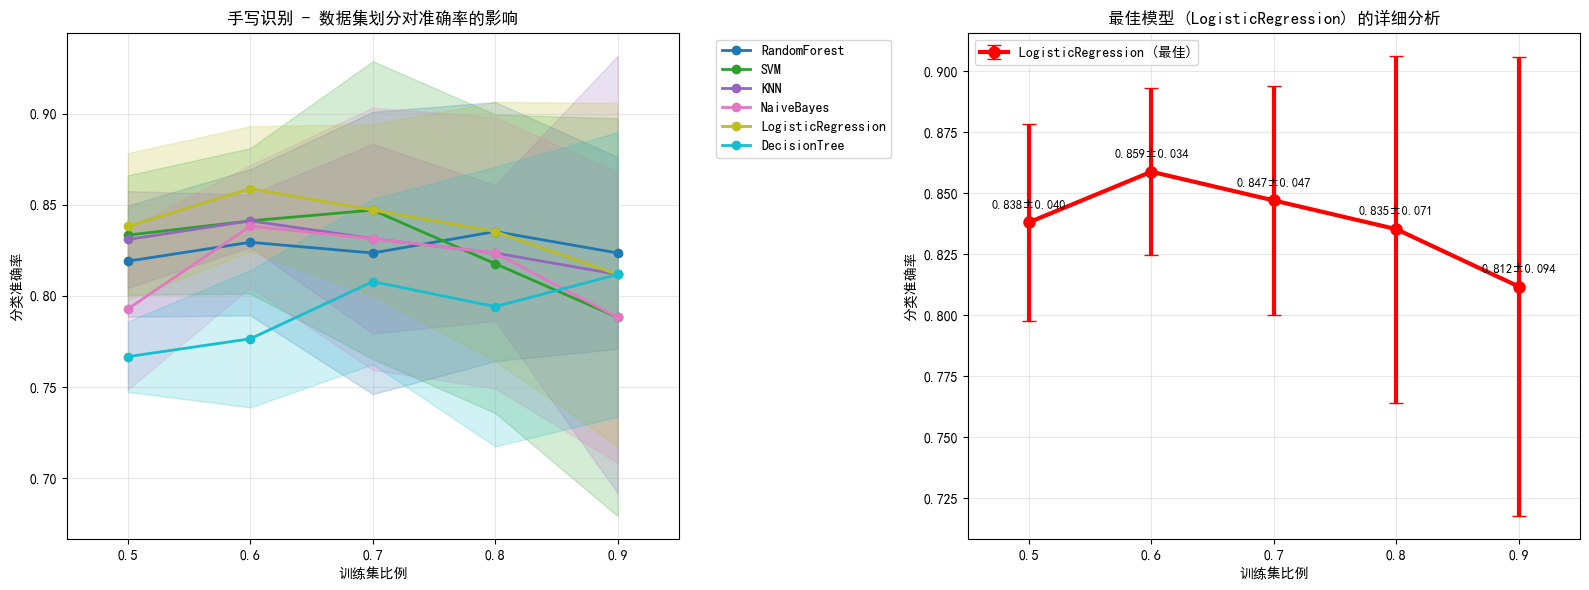

数据集划分分析报告已保存: ..\outputs\part3\handwriting_classification_dataset_split_analysis.txt

分析任务: 分布类型+手写识别
特征维度: (162, 36172)
标签分布: [13  5  5  4  2  4  4  7  2  2  2 42 21 29 11  4  2  3]
 某些类别样本数量过少 (最少: 2)，跳过此任务

执行任务: 分布类型分类
特征维度: (165, 36172)
标签分布: [18  9  3  5  4  9  2  2 63 40  6  4]
 使用分层抽样

训练 RandomForest
  准确率: 0.4545
  F1分数: 0.3474
  交叉验证: 0.3864 ± 0.0227

训练 SVM
  准确率: 0.3939
  F1分数: 0.2514
  交叉验证: 0.3864 ± 0.0076

训练 KNN
  准确率: 0.1818
  F1分数: 0.1729
  交叉验证: 0.2955 ± 0.0227

训练 NaiveBayes
  准确率: 0.2424
  F1分数: 0.1934
  交叉验证: 0.3409 ± 0.0076

训练 LogisticRegression
  准确率: 0.3333
  F1分数: 0.3006
  交叉验证: 0.2652 ± 0.0379

训练 DecisionTree
  准确率: 0.2424
  F1分数: 0.2468
  交叉验证: 0.2652 ± 0.0379

执行任务: 手写识别
特征维度: (168, 36172)
标签分布: [ 53 115]
 使用分层抽样

训练 RandomForest
  准确率: 0.8824
  F1分数: 0.8846
  交叉验证: 0.8057 ± 0.0798

训练 SVM
  准确率: 0.8529
  F1分数: 0.8566
  交叉验证: 0.8288 ± 0.1005

训练 KNN
  准确率: 0.8529
  F1分数: 0.8576
  交叉验证: 0.8436 ± 0.0713

训练 NaiveBayes
  准确率: 0.8824
  F1分数: 0.8824
  交叉验证: 0

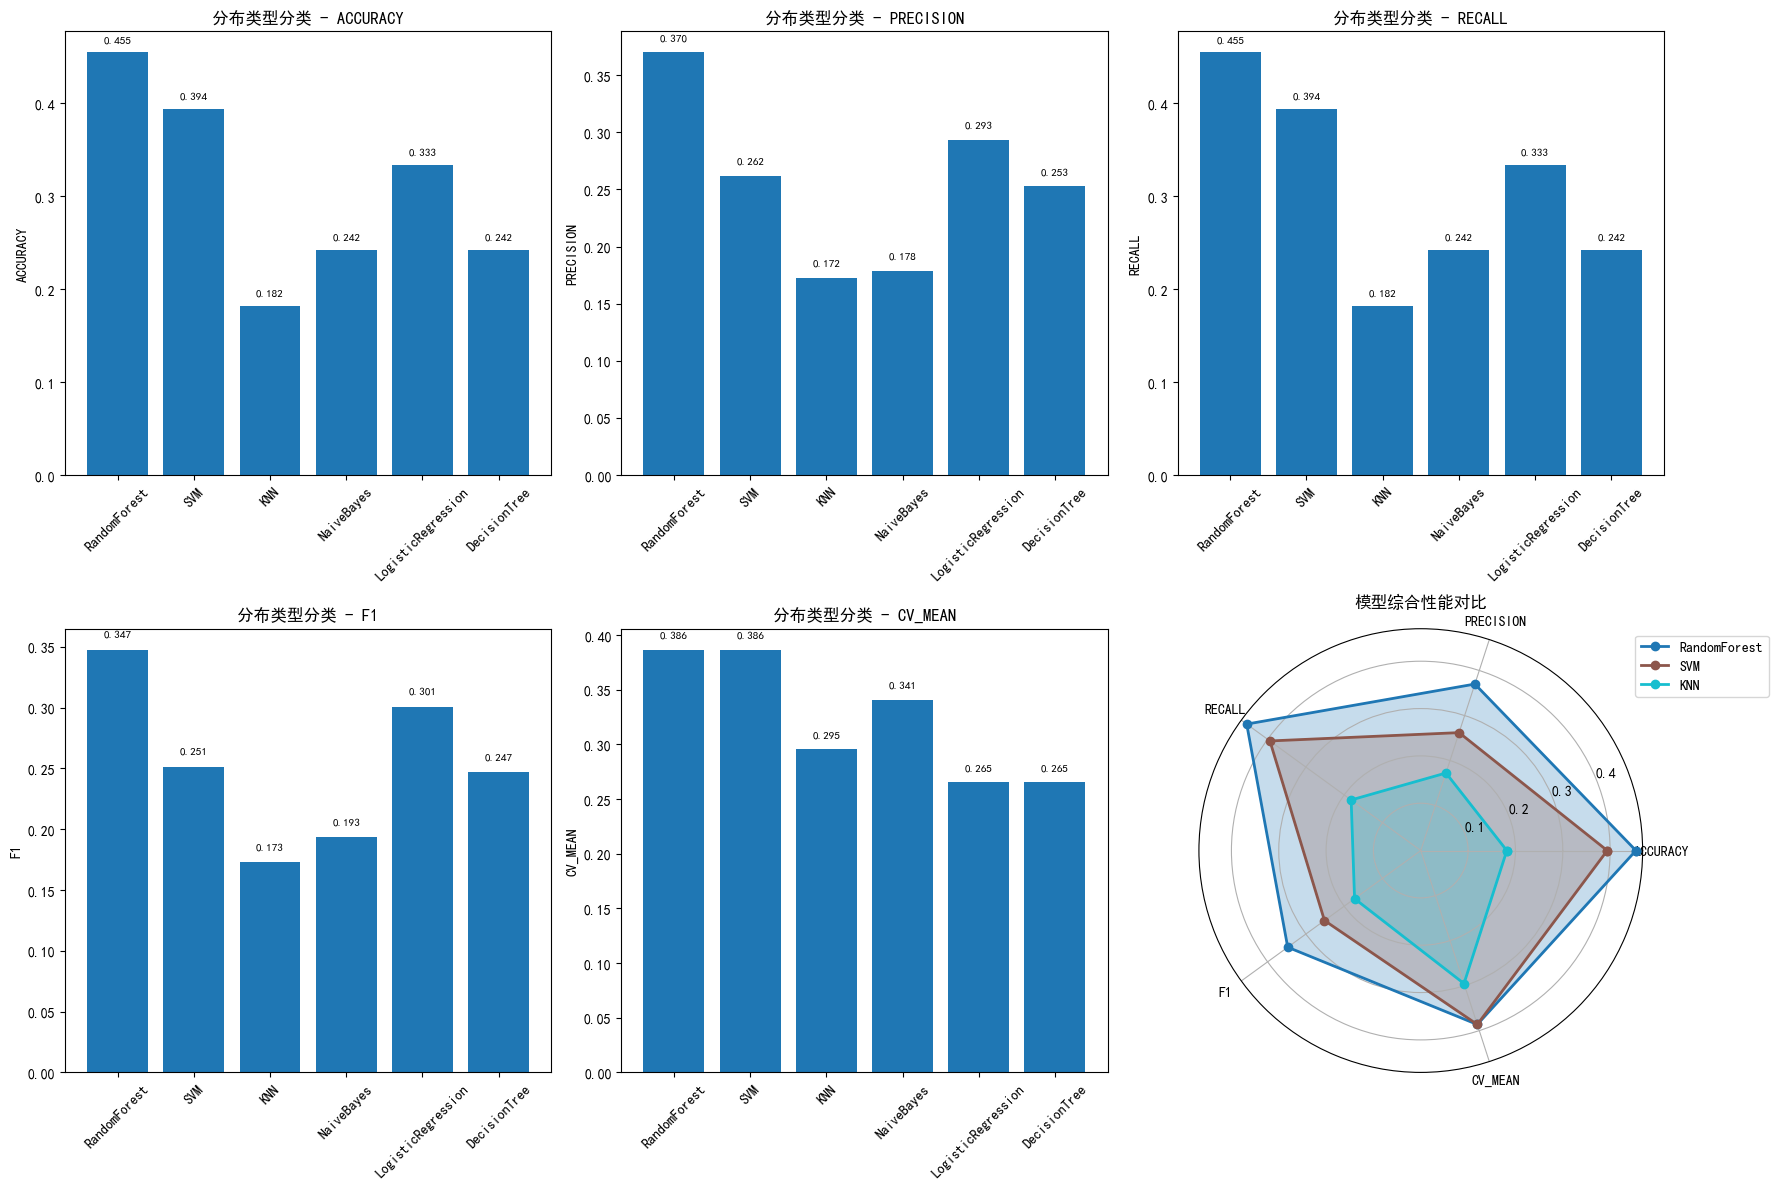

混淆矩阵已保存: ..\outputs\part3\distribution_classification_confusion_matrices.png


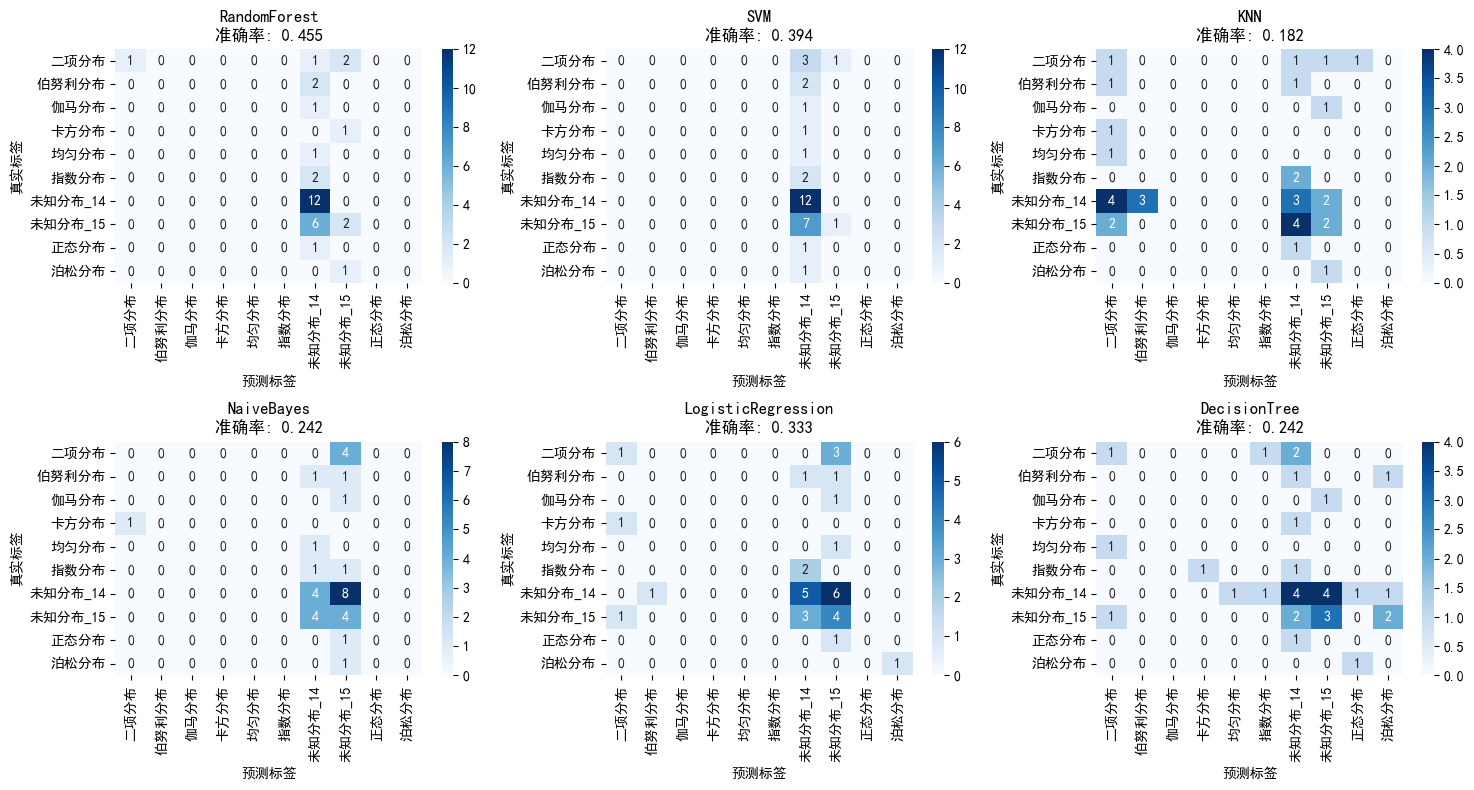

模型对比图已保存: ..\outputs\part3\handwriting_classification_model_comparison.png


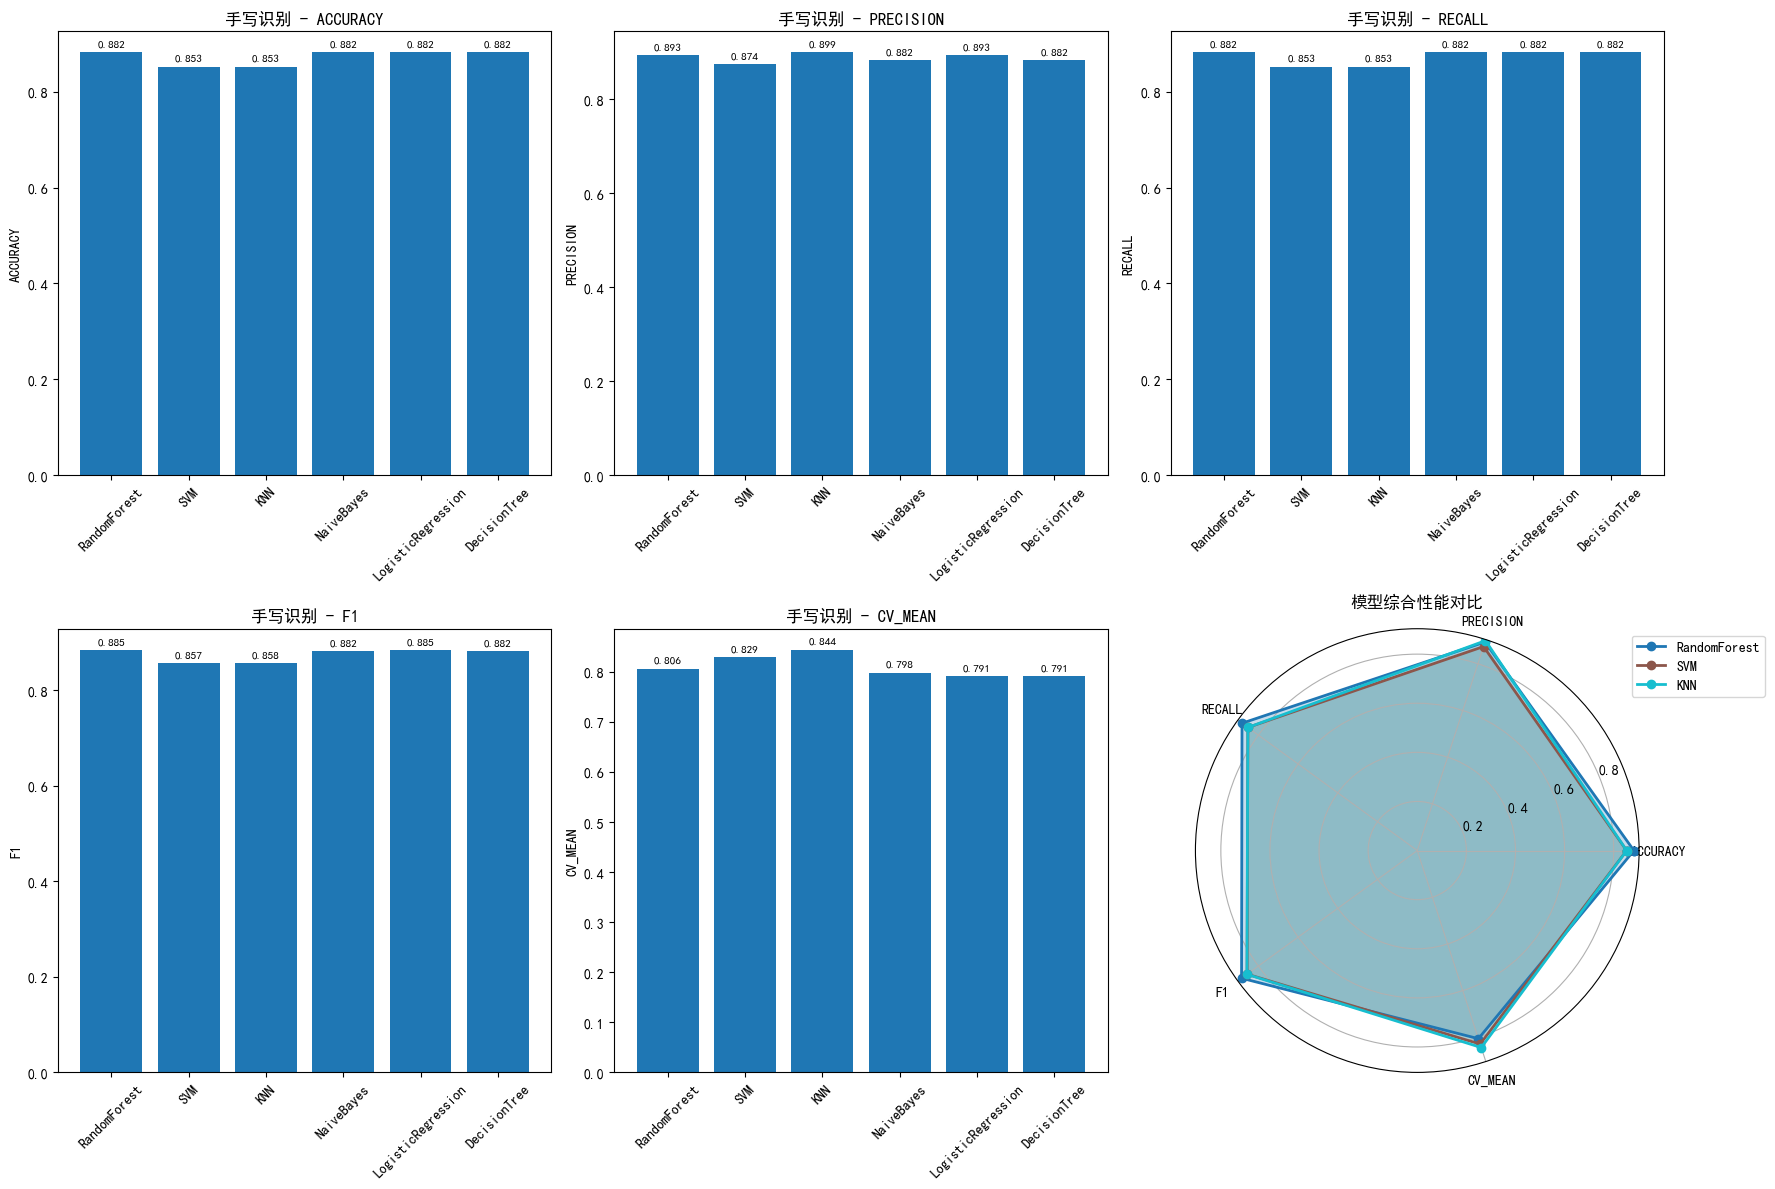

混淆矩阵已保存: ..\outputs\part3\handwriting_classification_confusion_matrices.png


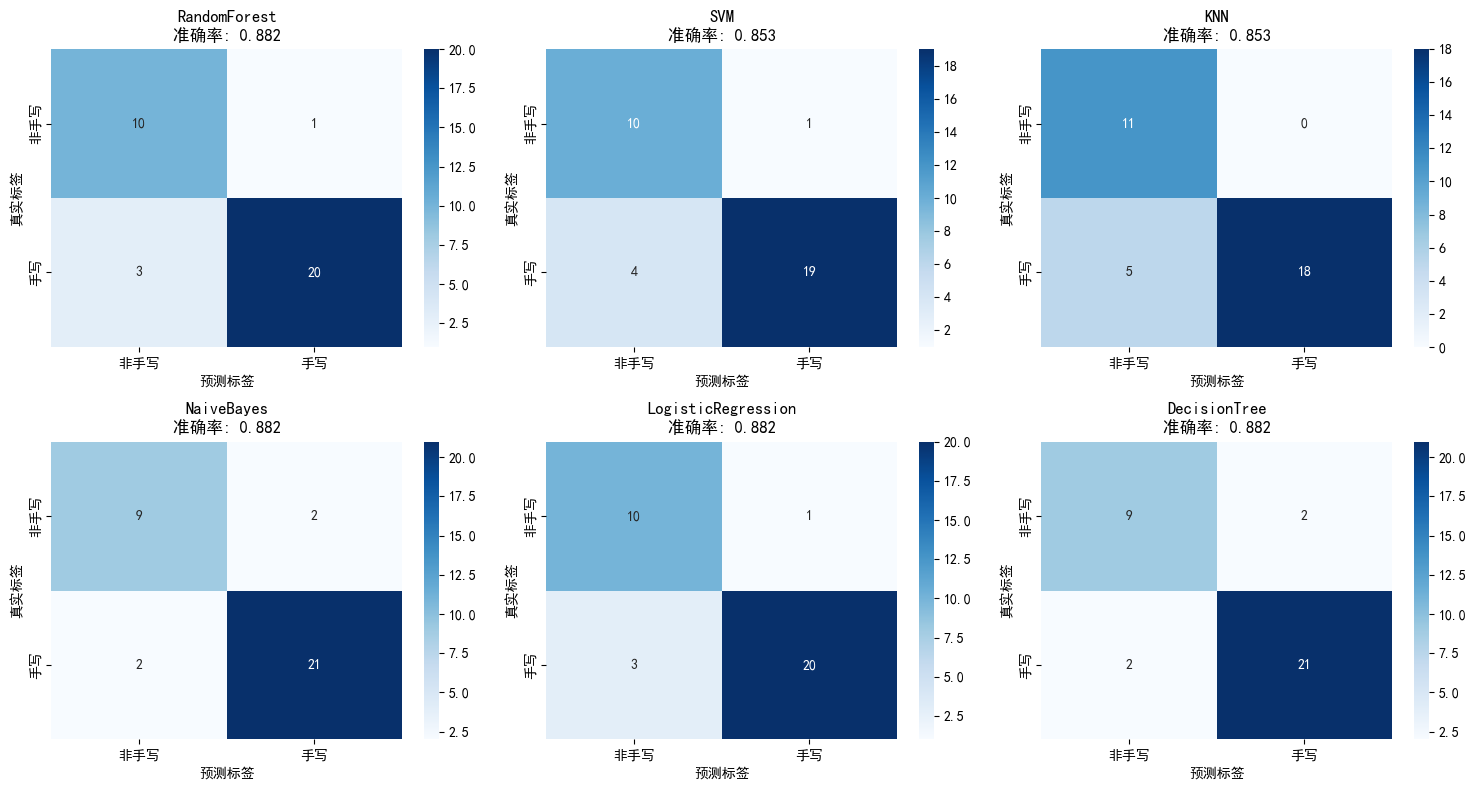

ROC曲线已保存: ..\outputs\part3\handwriting_classification_roc_curves.png


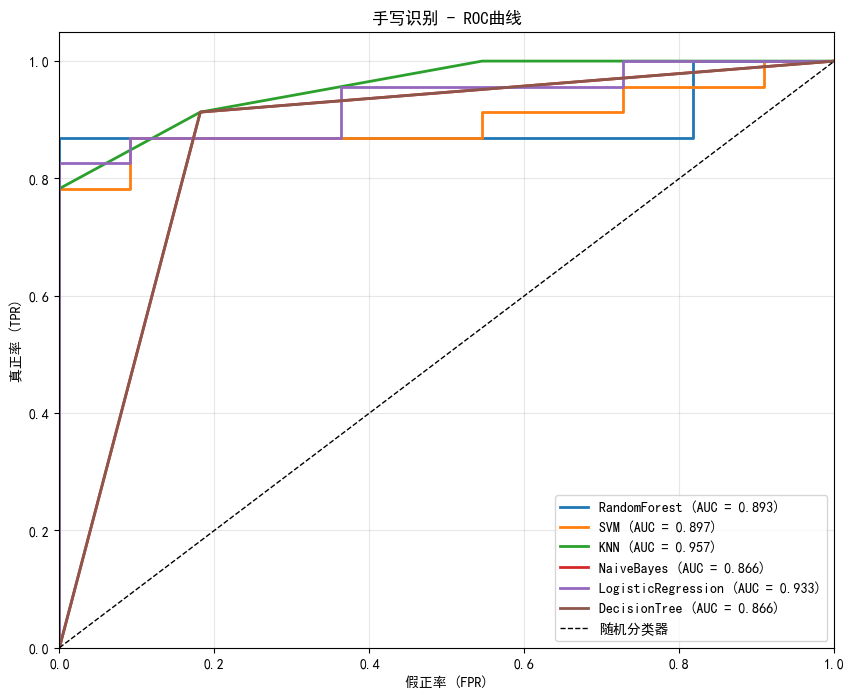

模型对比图已保存: ..\outputs\part3\multi_label_classification_model_comparison.png


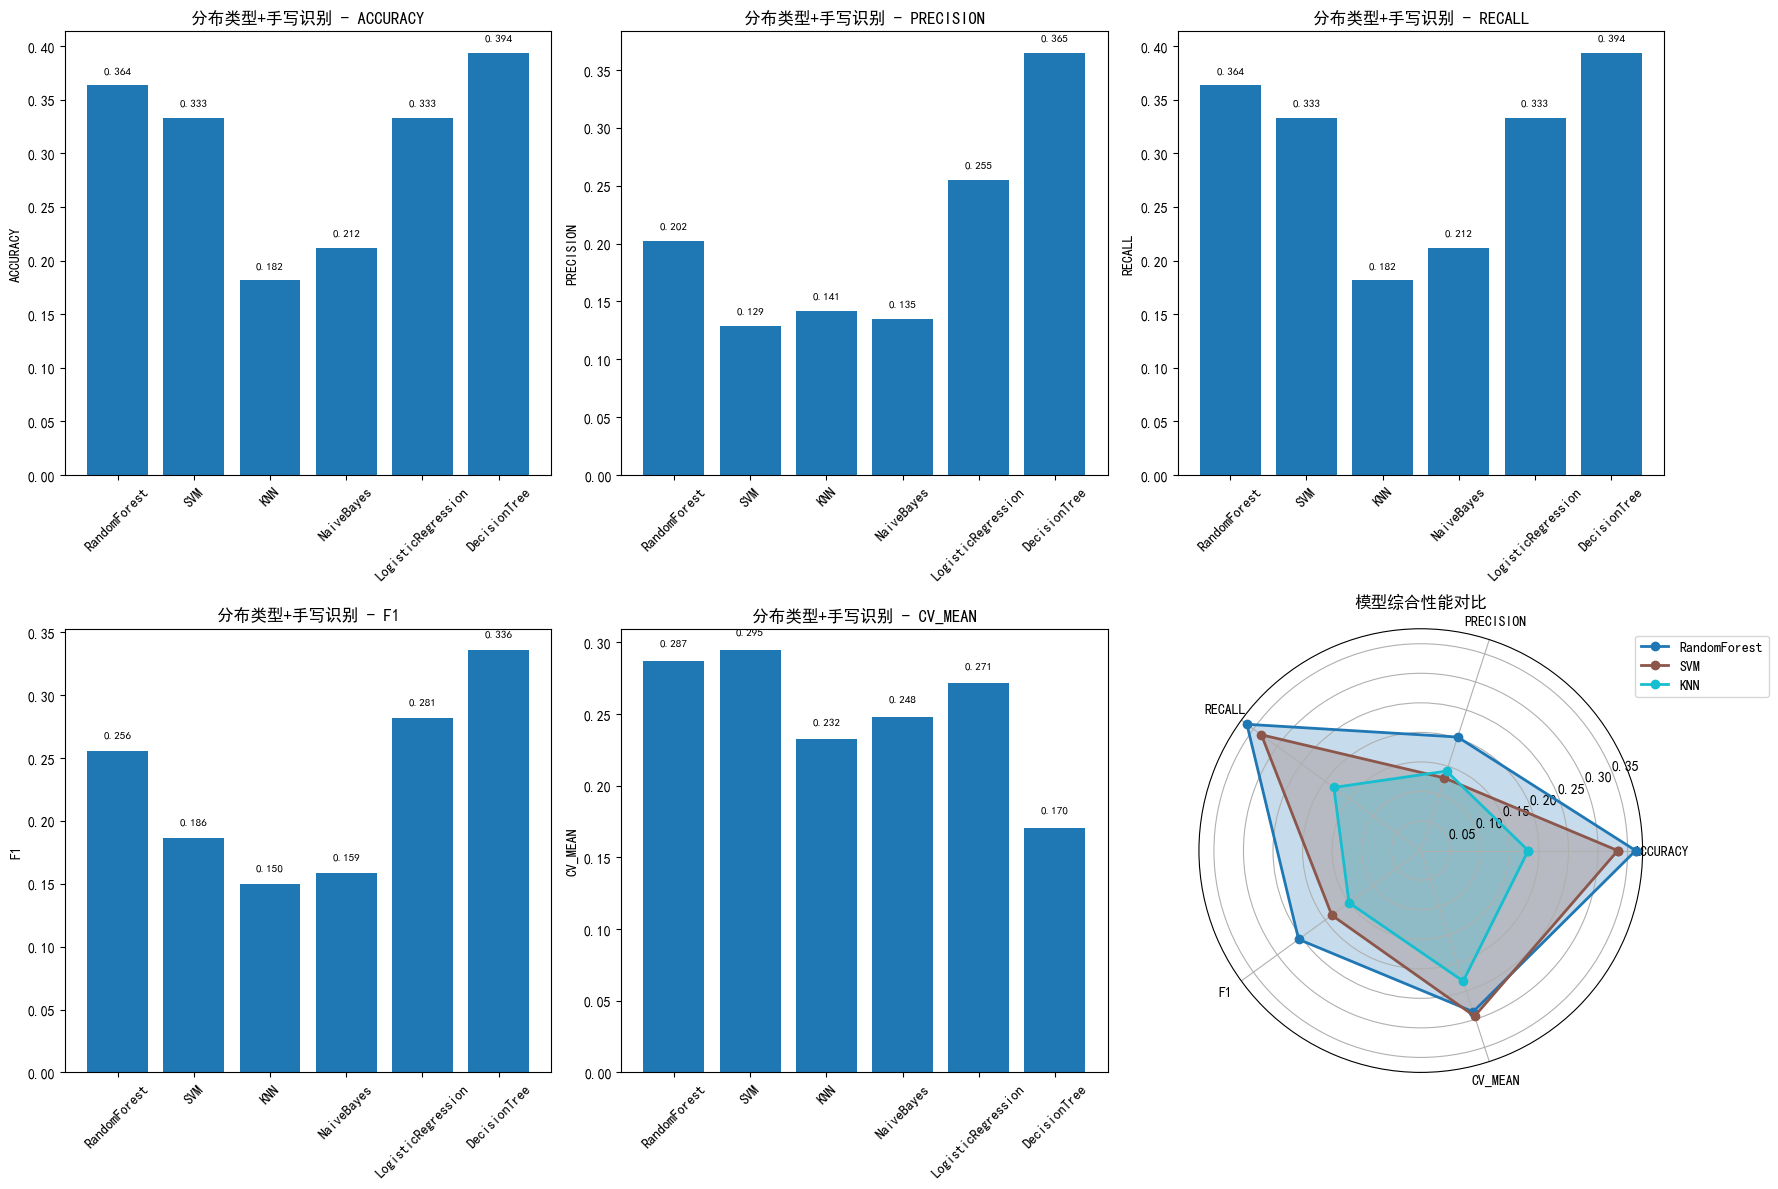

混淆矩阵已保存: ..\outputs\part3\multi_label_classification_confusion_matrices.png


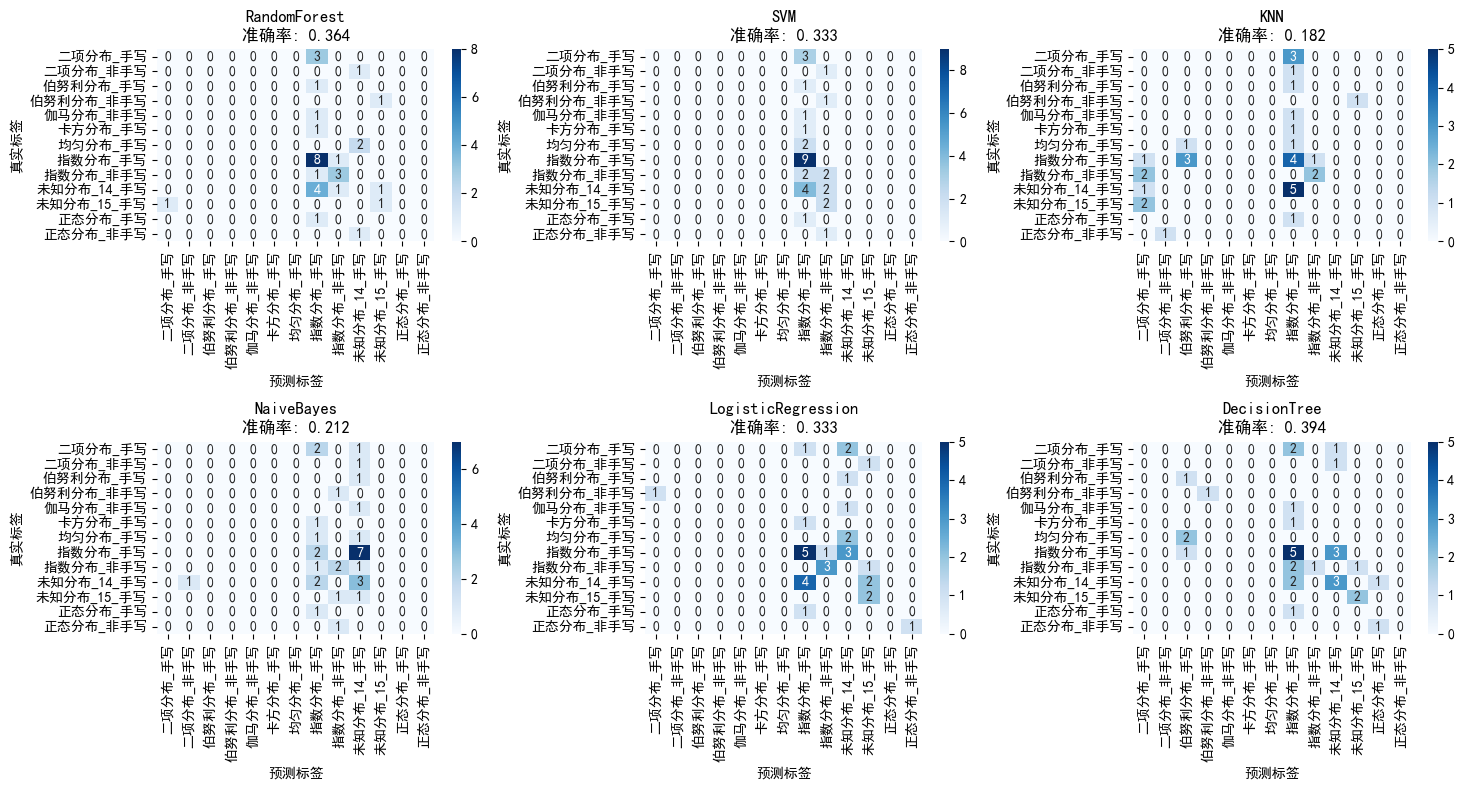


保存结果
结果汇总已保存: ..\outputs\part3\ml_classification_results.csv
详细结果已保存: ..\outputs\part3\ml_classification_detailed_results.pkl
文本报告已保存: ..\outputs\part3\ml_classification_report.txt

训练深度学习模型

开始深度学习模型训练

训练任务: 分布类型分类
特征维度: (165, 36172)
类别数量: 12

  训练 Simple_DNN
    准确率: 0.1212
    F1分数: 0.1111

  训练 Deep_DNN
    准确率: 0.1818
    F1分数: 0.1393

  训练 Wide_DNN
    准确率: 0.3333
    F1分数: 0.2113

训练任务: 手写识别
特征维度: (168, 36172)
类别数量: 2

  训练 Simple_DNN
    准确率: 0.6765
    F1分数: 0.6846

  训练 Deep_DNN
    准确率: 0.7353
    F1分数: 0.7435

  训练 Wide_DNN
    准确率: 0.7353
    F1分数: 0.7437

训练任务: 分布类型+手写识别
特征维度: (162, 36172)
类别数量: 18

  训练 Simple_DNN
    准确率: 0.0606
    F1分数: 0.0606

  训练 Deep_DNN
    准确率: 0.2727
    F1分数: 0.2739

  训练 Wide_DNN
    准确率: 0.2121
    F1分数: 0.2125

可视化深度学习训练历史
深度学习训练历史已保存: ..\outputs\part3\distribution_classification_dl_training_history.png


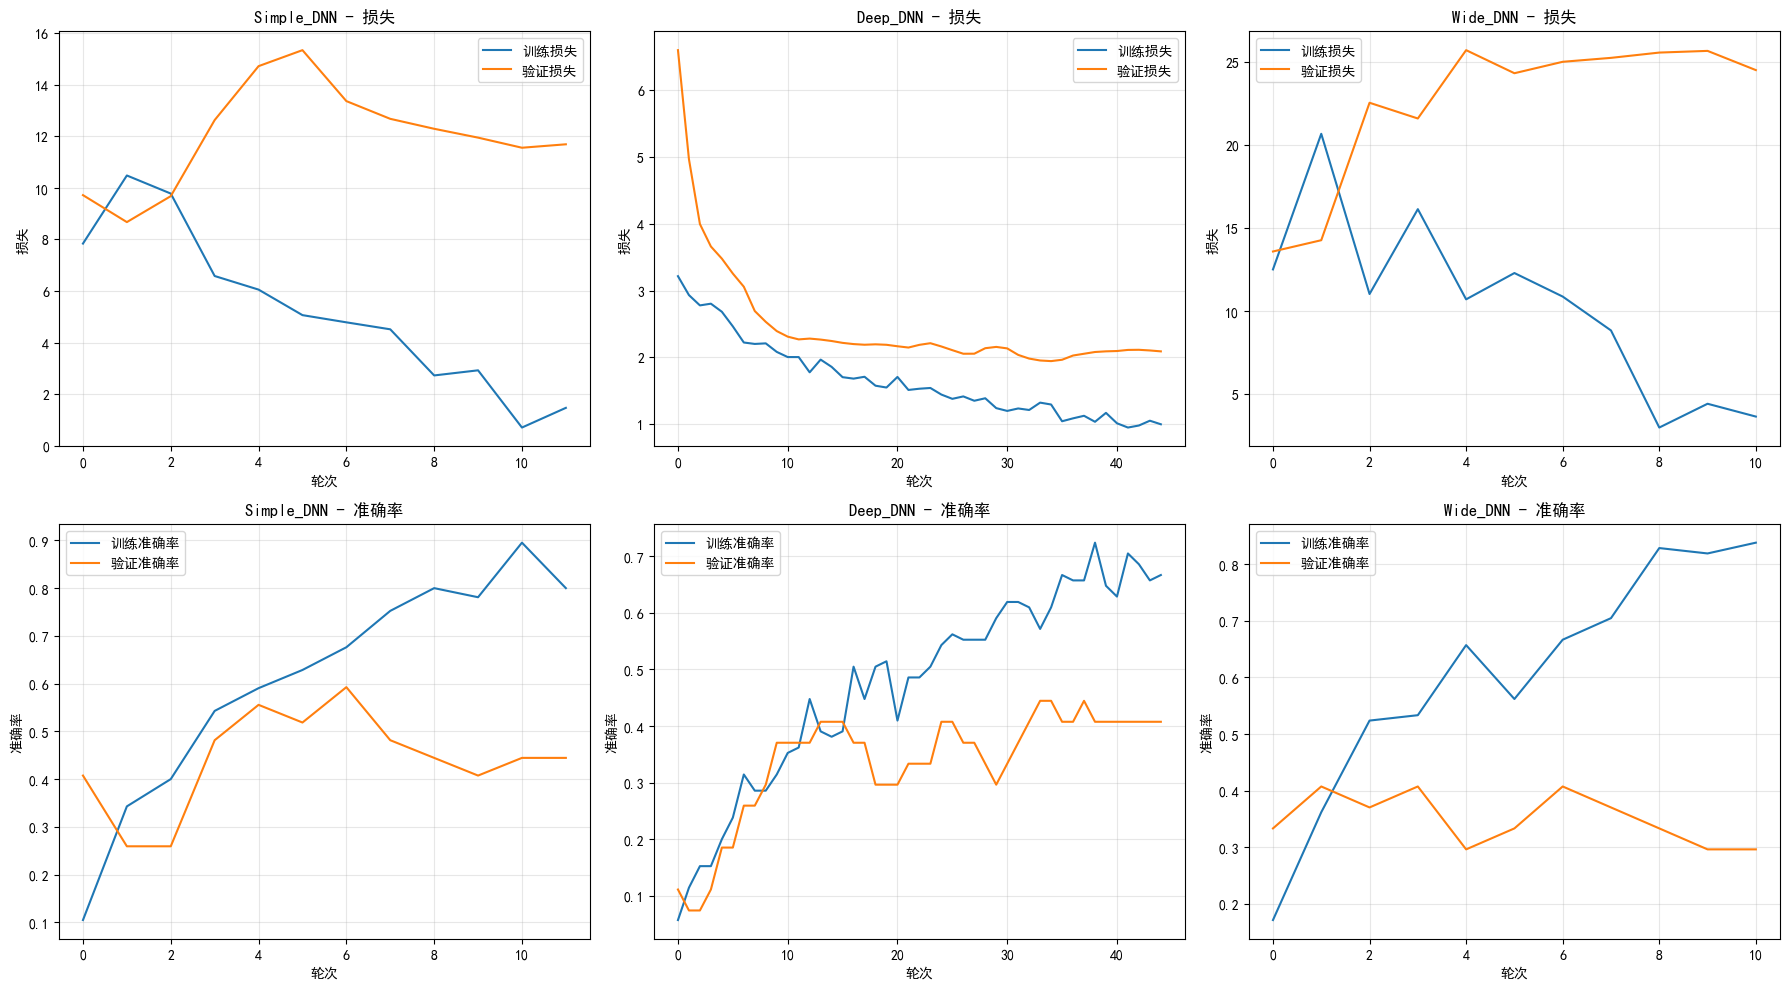

深度学习训练历史已保存: ..\outputs\part3\handwriting_classification_dl_training_history.png


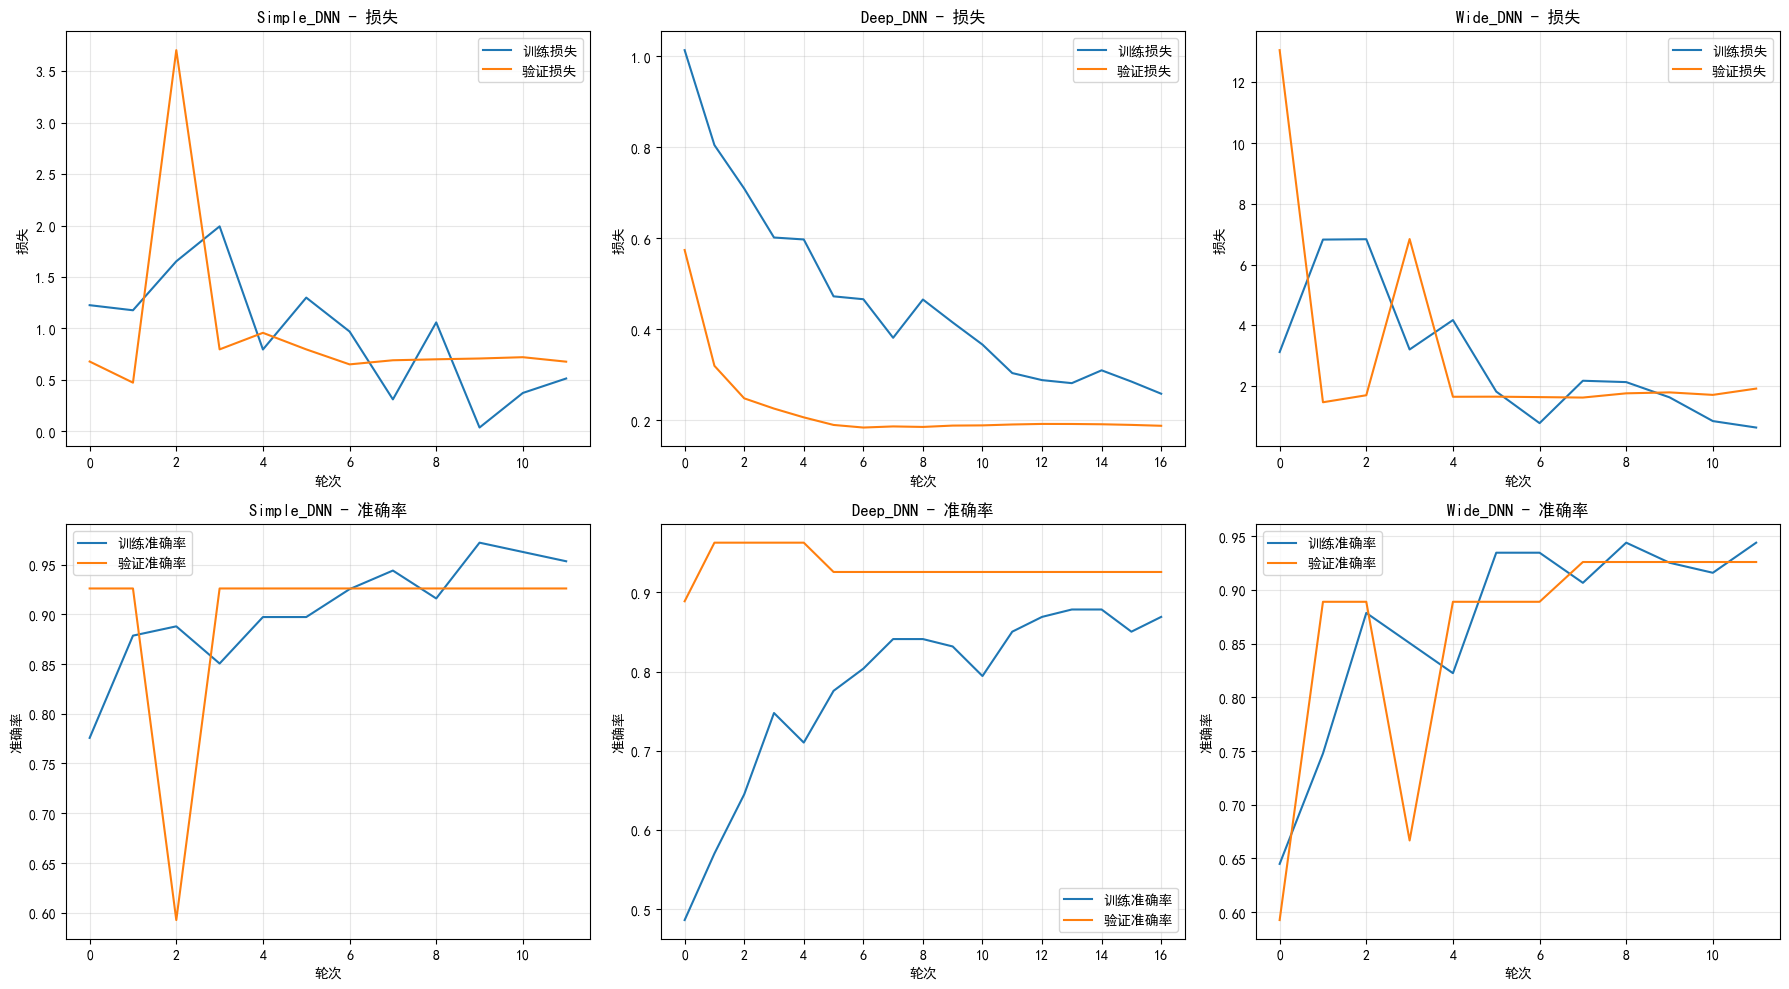

深度学习训练历史已保存: ..\outputs\part3\multi_label_classification_dl_training_history.png


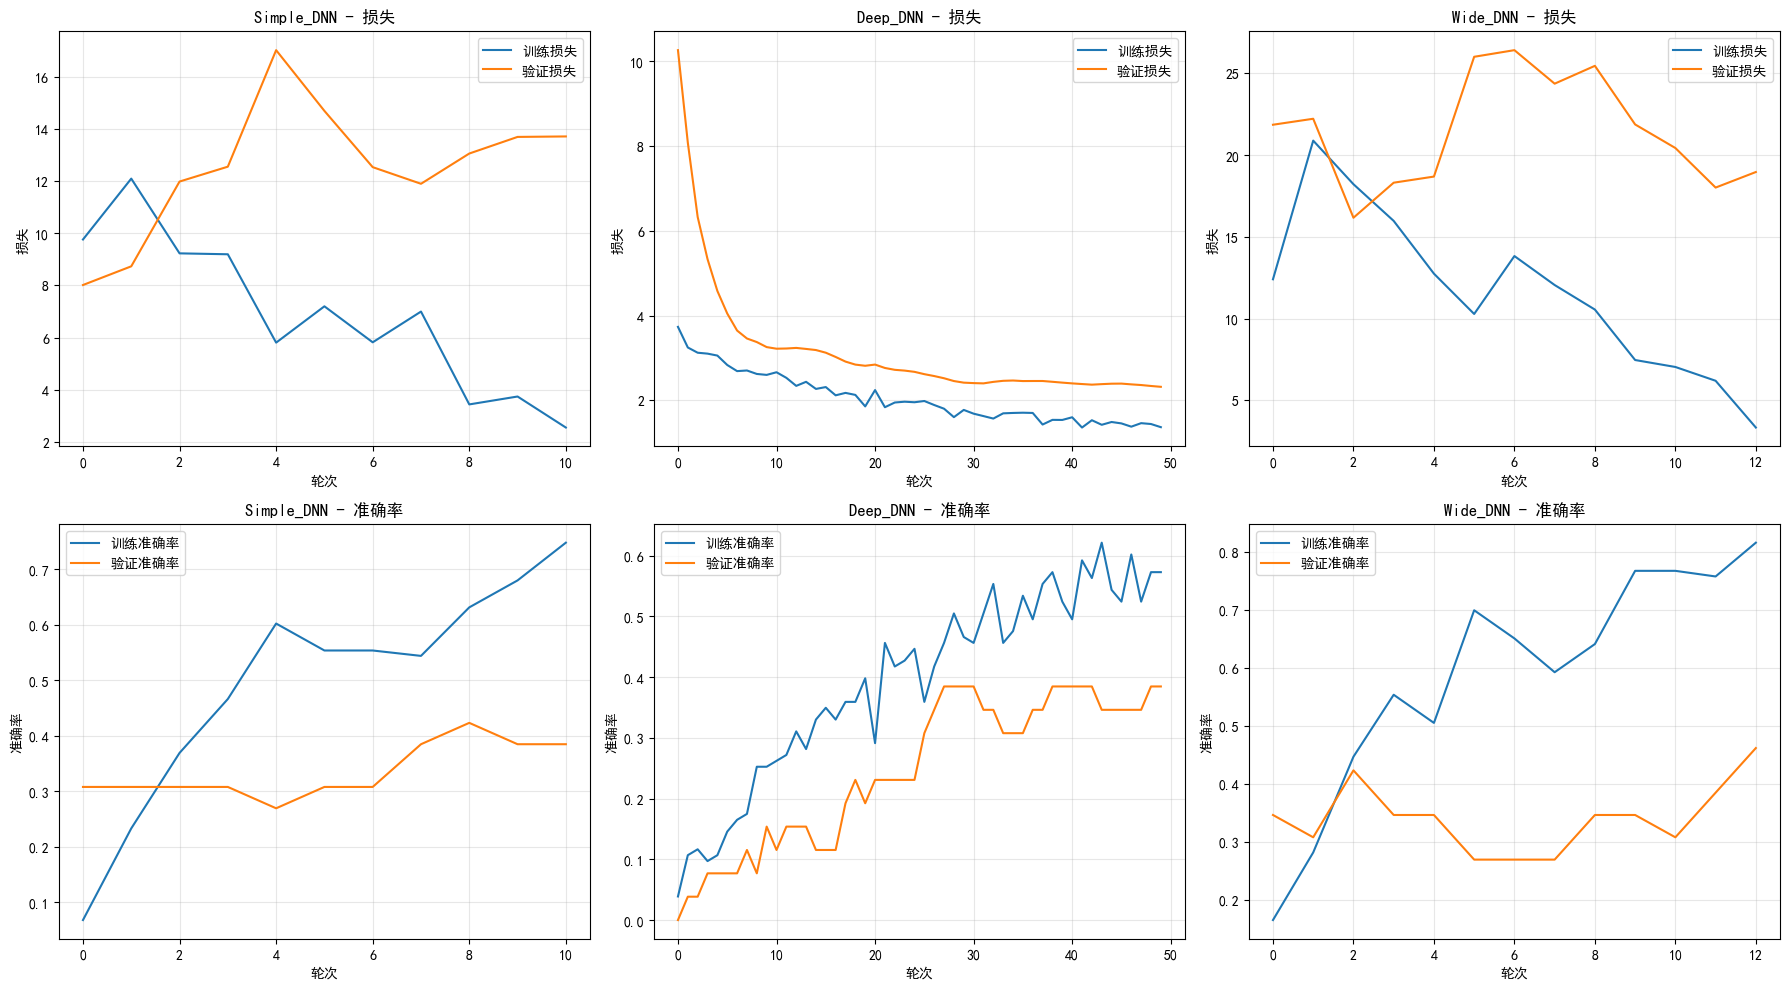


保存深度学习模型
  已保存: ..\outputs\part3\distribution_classification_Simple_DNN_model.h5


  已保存: ..\outputs\part3\distribution_classification_Deep_DNN_model.h5


  已保存: ..\outputs\part3\distribution_classification_Wide_DNN_model.h5


  已保存: ..\outputs\part3\handwriting_classification_Simple_DNN_model.h5


  已保存: ..\outputs\part3\handwriting_classification_Deep_DNN_model.h5


  已保存: ..\outputs\part3\handwriting_classification_Wide_DNN_model.h5
  已保存: ..\outputs\part3\multi_label_classification_Simple_DNN_model.h5


  已保存: ..\outputs\part3\multi_label_classification_Deep_DNN_model.h5
  已保存: ..\outputs\part3\multi_label_classification_Wide_DNN_model.h5

 生成的文件:
  - ml_classification_results.csv: 机器学习结果汇总
  - ml_classification_report.txt: 详细文本报告
  - *_model_comparison.png: 模型对比图
  - *_confusion_matrices.png: 混淆矩阵
  - *_roc_curves.png: ROC曲线
  - *_dataset_split_impact.png: 数据集划分影响图 (新增)
  - *_dataset_split_analysis.txt: 数据集划分分析报告 (新增)
  - *_dl_training_history.png: 深度学习训练历史
  - *.h5: 深度学习模型文件
  - *.pkl: 预处理器和详细结果


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

# 机器学习模型
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 深度学习模型
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 输出目录
output_dir = Path("../outputs/part3")
output_dir.mkdir(exist_ok=True, parents=True)

class MLClassificationPipeline:
    def __init__(self):
        """初始化机器学习分类管道"""
        self.models = {}
        self.results = {}
        self.label_encoder = LabelEncoder()
        
    def load_features(self, features_path="../outputs/part2"):
        """
        加载特征数据
        
        Args:
            features_path: 特征文件路径
            
        Returns:
            dict: 特征数据字典
        """
        features_path = Path(features_path)
        
        print("加载特征数据")
        print(f"从路径加载: {features_path.absolute()}")
        
        # 检查文件是否存在
        required_files = [
            'traditional_features.npy',
            'encoded_features.npy', 
            'combined_features.npy',
            'labels.npy',
            'handwritten.npy'
        ]
        
        missing_files = []
        for file in required_files:
            if not (features_path / file).exists():
                missing_files.append(file)
        
        if missing_files:
            print(f" 缺少以下文件: {missing_files}")
            print("请确保已运行第二部分代码并生成了特征文件")
            return None
        
        try:
            traditional_features = np.load(features_path / 'traditional_features.npy')
            encoded_features = np.load(features_path / 'encoded_features.npy')
            combined_features = np.load(features_path / 'combined_features.npy')
            labels = np.load(features_path / 'labels.npy')
            handwritten = np.load(features_path / 'handwritten.npy')
            
            print(f" 传统特征: {traditional_features.shape}")
            print(f" 编码特征: {encoded_features.shape}")
            print(f" 合并特征: {combined_features.shape}")
            print(f" 标签数量: {len(labels)}")
            print(f" 唯一标签: {np.unique(labels)}")
            
            # 检查数据一致性
            if len(set([len(traditional_features), len(encoded_features), 
                       len(combined_features), len(labels), len(handwritten)])) != 1:
                print(" 数据长度不一致")
                return None
            
            return {
                'traditional': traditional_features,
                'encoded': encoded_features,
                'combined': combined_features,
                'labels': labels,
                'handwritten': handwritten
            }
            
        except Exception as e:
            print(f" 加载特征文件时出错: {e}")
            return None
    
    def prepare_classification_tasks(self, data):
        """
        准备分类任务
        
        Args:
            data: 特征数据字典
            
        Returns:
            dict: 分类任务数据
        """
        tasks = {}
        
        print("\n准备分类任务")
        
        try:
            # 任务1: 分布类型分类
            unique_labels = np.unique(data['labels'])
            if len(unique_labels) > 1:
                # 检查每个类别的样本数量
                from collections import Counter
                label_counts = Counter(data['labels'])
                print(f"分布类型样本分布: {dict(label_counts)}")
                
                # 过滤掉样本数量少于2的类别
                valid_labels = [label for label, count in label_counts.items() if count >= 2]
                
                if len(valid_labels) > 1:
                    # 创建mask来过滤数据
                    mask = pd.Series(data['labels']).isin(valid_labels)
                    filtered_X = data['combined'][mask]
                    filtered_labels = data['labels'][mask]
                    
                    dist_labels_encoded = self.label_encoder.fit_transform(filtered_labels)
                    
                    tasks['distribution_classification'] = {
                        'X': filtered_X,
                        'y': dist_labels_encoded,
                        'y_names': filtered_labels,
                        'task_name': '分布类型分类',
                        'classes': self.label_encoder.classes_
                    }
                    print(f" 分布类型分类: {len(valid_labels)} 类 (过滤后)")
                else:
                    print(" 过滤后只剩一种分布类型，跳过分布分类任务")
            else:
                print(" 只有一种分布类型，跳过分布分类任务")
            
            # 任务2: 手写识别
            unique_handwritten = np.unique(data['handwritten'])
            if len(unique_handwritten) > 1:
                handwritten_counts = Counter(data['handwritten'])
                print(f"手写识别样本分布: {dict(handwritten_counts)}")
                
                # 检查每个类别是否有足够样本
                min_samples = min(handwritten_counts.values())
                if min_samples >= 2:
                    tasks['handwriting_classification'] = {
                        'X': data['combined'],
                        'y': data['handwritten'].astype(int),
                        'y_names': ['非手写', '手写'],
                        'task_name': '手写识别',
                        'classes': ['非手写', '手写']
                    }
                    print(f" 手写识别: 2 类")
                else:
                    print(" 手写识别类别样本数量不足，跳过手写识别任务")
            else:
                print(" 只有一种手写类型，跳过手写识别任务")
            
            # 任务3: 多标签分类（分布+手写）
            if len(unique_labels) > 1 and len(unique_handwritten) > 1:
                combined_labels = []
                for i in range(len(data['labels'])):
                    dist = data['labels'][i]
                    hand = '手写' if data['handwritten'][i] else '非手写'
                    combined_labels.append(f"{dist}_{hand}")
                
                # 检查组合标签的分布
                combined_counts = Counter(combined_labels)
                print(f"多标签样本分布: {dict(combined_counts)}")
                
                # 过滤掉样本数量少于2的组合类别
                valid_combined = [label for label, count in combined_counts.items() if count >= 2]
                
                if len(valid_combined) > 1:
                    # 创建mask来过滤数据
                    mask = pd.Series(combined_labels).isin(valid_combined)
                    filtered_X = data['combined'][mask]
                    filtered_combined_labels = np.array(combined_labels)[mask]
                    
                    combined_labels_encoded = LabelEncoder().fit_transform(filtered_combined_labels)
                    
                    tasks['multi_label_classification'] = {
                        'X': filtered_X,
                        'y': combined_labels_encoded,
                        'y_names': filtered_combined_labels,
                        'task_name': '分布类型+手写识别',
                        'classes': np.unique(filtered_combined_labels)
                    }
                    print(f" 多标签分类: {len(valid_combined)} 类 (过滤后)")
                else:
                    print(" 过滤后多标签类别不足，跳过多标签分类任务")
            else:
                print(" 数据不足以进行多标签分类")
            
            if not tasks:
                print(" 没有可执行的分类任务")
                return None
                
            return tasks
            
        except Exception as e:
            print(f" 准备分类任务时出错: {e}")
            return None
    
    def initialize_models(self):
        """初始化机器学习模型"""
        self.models = {
            'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
            'SVM': SVC(kernel='rbf', random_state=42, probability=True),
            'KNN': KNeighborsClassifier(n_neighbors=5),
            'NaiveBayes': GaussianNB(),
            'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
            'DecisionTree': DecisionTreeClassifier(random_state=42),
            #'GradientBoosting': GradientBoostingClassifier(n_estimators=30, max_depth=2, random_state=42)

        }
        
        print(f" 初始化了 {len(self.models)} 个机器学习模型")
    
    def analyze_dataset_split_impact(self, tasks):
        """
        分析数据集划分对分类精度的影响
        
        Args:
            tasks: 分类任务字典
        """
        print(f"\n{'='*50}")
        print("分析数据集划分对分类精度的影响")
        print(f"{'='*50}")
        
        # 测试不同的训练集比例
        train_sizes = [0.5, 0.6, 0.7, 0.8, 0.9]
        
        for task_name, task_data in tasks.items():
            print(f"\n分析任务: {task_data['task_name']}")
            
            X = task_data['X']
            y = task_data['y']
            
            # 检查数据
            print(f"特征维度: {X.shape}")
            print(f"标签分布: {np.bincount(y)}")
            
            # 检查是否有足够的样本进行分割
            min_class_count = np.min(np.bincount(y))
            if min_class_count < 5:  # 需要足够的样本进行多次分割
                print(f" 某些类别样本数量过少 (最少: {min_class_count})，跳过此任务")
                continue
            
            # 存储结果
            split_results = {}
            
            for train_size in train_sizes:
                print(f"\n  测试训练集比例: {train_size:.1f} (测试集: {1-train_size:.1f})")
                
                split_results[train_size] = {}
                
                for model_name, model in self.models.items():
                    try:
                        # 多次运行以获得稳定结果
                        accuracies = []
                        
                        for seed in range(42, 47):  # 5次随机种子
                            # 检查是否可以使用分层抽样
                            use_stratify = min_class_count >= 2
                            
                            if use_stratify:
                                X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, train_size=train_size, random_state=seed, stratify=y
                                )
                            else:
                                X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, train_size=train_size, random_state=seed
                                )
                            
                            # 标准化特征
                            scaler = StandardScaler()
                            X_train_scaled = scaler.fit_transform(X_train)
                            X_test_scaled = scaler.transform(X_test)
                            
                            # 训练模型
                            model_copy = type(model)(**model.get_params())
                            model_copy.fit(X_train_scaled, y_train)
                            
                            # 预测和评估
                            y_pred = model_copy.predict(X_test_scaled)
                            accuracy = accuracy_score(y_test, y_pred)
                            accuracies.append(accuracy)
                        
                        # 计算平均准确率和标准差
                        mean_accuracy = np.mean(accuracies)
                        std_accuracy = np.std(accuracies)
                        
                        split_results[train_size][model_name] = {
                            'mean_accuracy': mean_accuracy,
                            'std_accuracy': std_accuracy,
                            'accuracies': accuracies
                        }
                        
                        print(f"    {model_name}: {mean_accuracy:.4f} ± {std_accuracy:.4f}")
                        
                    except Exception as e:
                        print(f"     {model_name} 失败: {e}")
                        split_results[train_size][model_name] = None
            
            # 生成可视化
            self._plot_split_impact(task_name, task_data, split_results, train_sizes)
    
    def _plot_split_impact(self, task_name, task_data, split_results, train_sizes):
        """
        绘制数据集划分对分类精度影响的曲线图
        
        Args:
            task_name: 任务名称
            task_data: 任务数据
            split_results: 分割结果
            train_sizes: 训练集大小列表
        """
        try:
            # 创建图形
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
            
            # 图1: 所有模型的准确率曲线
            colors = plt.cm.tab10(np.linspace(0, 1, len(self.models)))
            
            for i, model_name in enumerate(self.models.keys()):
                mean_accuracies = []
                std_accuracies = []
                
                for train_size in train_sizes:
                    result = split_results.get(train_size, {}).get(model_name)
                    if result is not None:
                        mean_accuracies.append(result['mean_accuracy'])
                        std_accuracies.append(result['std_accuracy'])
                    else:
                        mean_accuracies.append(np.nan)
                        std_accuracies.append(np.nan)
                
                # 过滤掉NaN值
                valid_indices = ~np.isnan(mean_accuracies)
                if np.any(valid_indices):
                    valid_train_sizes = np.array(train_sizes)[valid_indices]
                    valid_means = np.array(mean_accuracies)[valid_indices]
                    valid_stds = np.array(std_accuracies)[valid_indices]
                    
                    # 绘制均值曲线
                    ax1.plot(valid_train_sizes, valid_means, 'o-', 
                            color=colors[i], label=model_name, linewidth=2, markersize=6)
                    
                    # 绘制误差带
                    ax1.fill_between(valid_train_sizes, 
                                    valid_means - valid_stds, 
                                    valid_means + valid_stds,
                                    color=colors[i], alpha=0.2)
            
            ax1.set_xlabel('训练集比例')
            ax1.set_ylabel('分类准确率')
            ax1.set_title(f'{task_data["task_name"]} - 数据集划分对准确率的影响')
            ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            ax1.grid(True, alpha=0.3)
            ax1.set_xlim(0.45, 0.95)
            
            # 图2: 最佳模型的详细分析
            # 找到平均性能最好的模型
            best_model = None
            best_avg_score = 0
            
            for model_name in self.models.keys():
                scores = []
                for train_size in train_sizes:
                    result = split_results.get(train_size, {}).get(model_name)
                    if result is not None:
                        scores.append(result['mean_accuracy'])
                
                if scores:
                    avg_score = np.mean(scores)
                    if avg_score > best_avg_score:
                        best_avg_score = avg_score
                        best_model = model_name
            
            if best_model:
                # 绘制最佳模型的详细结果
                best_means = []
                best_stds = []
                
                for train_size in train_sizes:
                    result = split_results.get(train_size, {}).get(best_model)
                    if result is not None:
                        best_means.append(result['mean_accuracy'])
                        best_stds.append(result['std_accuracy'])
                    else:
                        best_means.append(np.nan)
                        best_stds.append(np.nan)
                
                valid_indices = ~np.isnan(best_means)
                if np.any(valid_indices):
                    valid_train_sizes = np.array(train_sizes)[valid_indices]
                    valid_means = np.array(best_means)[valid_indices]
                    valid_stds = np.array(best_stds)[valid_indices]
                    
                    ax2.errorbar(valid_train_sizes, valid_means, yerr=valid_stds,
                               fmt='o-', linewidth=3, markersize=8, capsize=5,
                               color='red', label=f'{best_model} (最佳)')
                    
                    # 添加数据标签
                    for x, y, std in zip(valid_train_sizes, valid_means, valid_stds):
                        ax2.annotate(f'{y:.3f}±{std:.3f}', 
                                   (x, y), textcoords="offset points", 
                                   xytext=(0,10), ha='center', fontsize=9)
            
            ax2.set_xlabel('训练集比例')
            ax2.set_ylabel('分类准确率')
            ax2.set_title(f'最佳模型 ({best_model}) 的详细分析')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            ax2.set_xlim(0.45, 0.95)
            
            plt.tight_layout()
            
            # 保存图像
            save_path = output_dir / f"{task_name}_dataset_split_impact.png"
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"数据集划分影响图已保存: {save_path}")
            plt.show()
            
            # 生成分析报告
            self._generate_split_analysis_report(task_name, task_data, split_results, train_sizes, best_model)
            
        except Exception as e:
            print(f" 绘制数据集划分影响图时出错: {e}")
    
    def _generate_split_analysis_report(self, task_name, task_data, split_results, train_sizes, best_model):
        """
        生成数据集划分分析报告
        
        Args:
            task_name: 任务名称
            task_data: 任务数据
            split_results: 分割结果
            train_sizes: 训练集大小列表
            best_model: 最佳模型名称
        """
        try:
            report_path = output_dir / f"{task_name}_dataset_split_analysis.txt"
            
            with open(report_path, 'w', encoding='utf-8') as f:
                f.write("=" * 60 + "\n")
                f.write(f"{task_data['task_name']} - 数据集划分影响分析报告\n")
                f.write("=" * 60 + "\n\n")
                
                f.write("1. 实验设置:\n")
                f.write(f"   - 测试的训练集比例: {train_sizes}\n")
                f.write(f"   - 每个比例运行次数: 5次 (随机种子42-46)\n")
                f.write(f"   - 评估指标: 分类准确率\n")
                f.write(f"   - 特征维度: {task_data['X'].shape}\n")
                f.write(f"   - 类别数量: {len(task_data['classes'])}\n\n")
                
                f.write("2. 各模型在不同训练集比例下的性能:\n")
                f.write("-" * 40 + "\n")
                
                for train_size in train_sizes:
                    f.write(f"\n训练集比例 {train_size:.1f} (测试集 {1-train_size:.1f}):\n")
                    
                    # 排序结果
                    size_results = split_results.get(train_size, {})
                    sorted_results = sorted(
                        [(name, result) for name, result in size_results.items() if result is not None],
                        key=lambda x: x[1]['mean_accuracy'],
                        reverse=True
                    )
                    
                    for model_name, result in sorted_results:
                        f.write(f"  {model_name:15s}: {result['mean_accuracy']:.4f} ± {result['std_accuracy']:.4f}\n")
                
                f.write(f"\n3. 最佳模型分析 ({best_model}):\n")
                f.write("-" * 40 + "\n")
                
                best_results = []
                for train_size in train_sizes:
                    result = split_results.get(train_size, {}).get(best_model)
                    if result is not None:
                        best_results.append((train_size, result['mean_accuracy'], result['std_accuracy']))
                
                if best_results:
                    # 找到最佳训练集比例
                    best_split = max(best_results, key=lambda x: x[1])
                    f.write(f"最佳训练集比例: {best_split[0]:.1f} (准确率: {best_split[1]:.4f})\n")
                    
                    # 性能趋势分析
                    accuracies = [r[1] for r in best_results]
                    if len(accuracies) > 1:
                        trend = "上升" if accuracies[-1] > accuracies[0] else "下降"
                        f.write(f"性能趋势: 随训练集增大呈{trend}趋势\n")
                        
                        # 计算性能变化幅度
                        max_acc = max(accuracies)
                        min_acc = min(accuracies)
                        f.write(f"性能变化幅度: {max_acc - min_acc:.4f} ({(max_acc - min_acc)/min_acc*100:.2f}%)\n")
                
                f.write(f"\n4. 总结和建议:\n")
                f.write("-" * 40 + "\n")
                
                # 根据结果给出建议
                if best_results:
                    best_train_size = best_split[0]
                    if best_train_size >= 0.8:
                        f.write("- 建议使用较大的训练集比例(≥0.8)以获得更好的性能\n")
                    elif best_train_size <= 0.6:
                        f.write("- 较小的训练集比例已能达到良好性能，可能存在过拟合风险\n")
                    else:
                        f.write(f"- 建议使用{best_train_size:.1f}左右的训练集比例作为最佳平衡点\n")
                    
                    # 稳定性分析
                    avg_std = np.mean([r[2] for r in best_results])
                    if avg_std < 0.02:
                        f.write("- 模型性能稳定，对数据划分不敏感\n")
                    elif avg_std > 0.05:
                        f.write("- 模型性能波动较大，建议增加训练数据或调整模型复杂度\n")
                    else:
                        f.write("- 模型性能相对稳定\n")
            
            print(f"数据集划分分析报告已保存: {report_path}")
            
        except Exception as e:
            print(f" 生成数据集划分分析报告时出错: {e}")
    
    def train_and_evaluate_models(self, tasks):
        """
        训练和评估所有模型
        
        Args:
            tasks: 分类任务字典
        """
        self.results = {}
        
        for task_name, task_data in tasks.items():
            print(f"\n{'='*50}")
            print(f"执行任务: {task_data['task_name']}")
            print(f"{'='*50}")
            
            X = task_data['X']
            y = task_data['y']
            
            # 检查数据
            print(f"特征维度: {X.shape}")
            print(f"标签分布: {np.bincount(y)}")
            
            # 检查是否有足够的样本进行分割
            min_class_count = np.min(np.bincount(y))
            if min_class_count < 2:
                print(f" 某些类别样本数量过少 (最少: {min_class_count})，跳过此任务")
                continue
            
            try:
                # 检查是否可以使用分层抽样
                use_stratify = min_class_count >= 2
                
                if use_stratify:
                    # 使用分层抽样
                    X_train, X_test, y_train, y_test = train_test_split(
                        X, y, test_size=0.2, random_state=42, stratify=y
                    )
                    print(" 使用分层抽样")
                else:
                    # 不使用分层抽样
                    X_train, X_test, y_train, y_test = train_test_split(
                        X, y, test_size=0.2, random_state=42
                    )
                    print(" 不使用分层抽样（样本数量不足）")
                
                # 标准化特征
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X_test)
                
                task_results = {}
                
                # 训练每个模型
                for model_name, model in self.models.items():
                    print(f"\n训练 {model_name}")
                    
                    try:
                        # 训练模型
                        model.fit(X_train_scaled, y_train)
                        
                        # 预测
                        y_pred = model.predict(X_test_scaled)
                        y_pred_proba = None
                        
                        if hasattr(model, 'predict_proba'):
                            y_pred_proba = model.predict_proba(X_test_scaled)
                        
                        # 计算指标
                        accuracy = accuracy_score(y_test, y_pred)
                        precision, recall, f1, _ = precision_recall_fscore_support(
                            y_test, y_pred, average='weighted', zero_division=0
                        )
                        
                        # 交叉验证
                        try:
                            cv_folds = min(5, min_class_count)
                            cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_folds)
                        except:
                            cv_scores = np.array([accuracy])  # 如果交叉验证失败，使用测试准确率
                        
                        task_results[model_name] = {
                            'accuracy': accuracy,
                            'precision': precision,
                            'recall': recall,
                            'f1': f1,
                            'cv_mean': cv_scores.mean(),
                            'cv_std': cv_scores.std(),
                            'y_test': y_test,
                            'y_pred': y_pred,
                            'y_pred_proba': y_pred_proba,
                            'model': model,
                            'scaler': scaler
                        }
                        
                        print(f"  准确率: {accuracy:.4f}")
                        print(f"  F1分数: {f1:.4f}")
                        print(f"  交叉验证: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
                        
                    except Exception as e:
                        print(f"   训练失败: {e}")
                        task_results[model_name] = None
                
                self.results[task_name] = {
                    'task_info': task_data,
                    'results': task_results
                }
                
            except Exception as e:
                print(f" 任务执行失败: {e}")
                continue
    
    def visualize_results(self):
        """可视化结果"""
        print(f"\n{'='*50}")
        print("生成可视化结果")
        print(f"{'='*50}")
        
        for task_name, task_result in self.results.items():
            task_info = task_result['task_info']
            results = task_result['results']
            
            # 过滤掉失败的结果
            valid_results = {k: v for k, v in results.items() if v is not None}
            
            if not valid_results:
                print(f" 任务 {task_name} 没有有效结果，跳过可视化")
                continue
            
            try:
                # 创建结果对比图
                self._plot_model_comparison(task_name, task_info, valid_results)
                
                # 创建混淆矩阵
                self._plot_confusion_matrices(task_name, task_info, valid_results)
                
                # 创建ROC曲线（仅二分类）
                if len(task_info['classes']) == 2:
                    self._plot_roc_curves(task_name, task_info, valid_results)
                    
            except Exception as e:
                print(f" 可视化任务 {task_name} 时出错: {e}")
    
    def _plot_model_comparison(self, task_name, task_info, results):
        """绘制模型对比图"""
        try:
            metrics = ['accuracy', 'precision', 'recall', 'f1', 'cv_mean']
            model_names = []
            metric_values = {metric: [] for metric in metrics}
            
            for model_name, result in results.items():
                if result is not None:
                    model_names.append(model_name)
                    for metric in metrics:
                        metric_values[metric].append(result[metric])
            
            if not model_names:
                return
            
            # 创建对比图
            fig, axes = plt.subplots(2, 3, figsize=(18, 12))
            axes = axes.flatten()
            
            for i, metric in enumerate(metrics):
                if i < len(axes):
                    bars = axes[i].bar(model_names, metric_values[metric])
                    axes[i].set_title(f'{task_info["task_name"]} - {metric.upper()}')
                    axes[i].set_ylabel(metric.upper())
                    axes[i].tick_params(axis='x', rotation=45)
                    
                    # 添加数值标签
                    for bar, value in zip(bars, metric_values[metric]):
                        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                                   f'{value:.3f}', ha='center', va='bottom', fontsize=8)
            
            # 综合对比雷达图
            if len(axes) > 5 and len(model_names) > 0:
                ax_radar = axes[5]
                ax_radar.remove()
                ax_radar = fig.add_subplot(2, 3, 6, projection='polar')
                
                angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
                angles += angles[:1]  # 闭合
                
                colors = plt.cm.tab10(np.linspace(0, 1, min(len(model_names), 3)))
                
                for i, model_name in enumerate(model_names[:3]):  # 只显示前3个模型
                    values = [metric_values[metric][i] for metric in metrics]
                    values += values[:1]  # 闭合
                    
                    ax_radar.plot(angles, values, 'o-', linewidth=2, label=model_name, color=colors[i])
                    ax_radar.fill(angles, values, alpha=0.25, color=colors[i])
                
                ax_radar.set_xticks(angles[:-1])
                ax_radar.set_xticklabels([m.upper() for m in metrics])
                ax_radar.set_title('模型综合性能对比')
                ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
            
            plt.tight_layout()
            save_path = output_dir / f"{task_name}_model_comparison.png"
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"模型对比图已保存: {save_path}")
            plt.show()
            
        except Exception as e:
            print(f" 绘制模型对比图时出错: {e}")
    
    def _plot_confusion_matrices(self, task_name, task_info, results):
        """绘制混淆矩阵"""
        try:
            n_models = len([r for r in results.values() if r is not None])
            if n_models == 0:
                return
            
            cols = min(3, n_models)
            rows = (n_models + cols - 1) // cols
            
            fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
            if n_models == 1:
                axes = [axes]
            elif rows == 1:
                axes = axes if isinstance(axes, (list, np.ndarray)) else [axes]
            else:
                axes = axes.flatten()
            
            plot_idx = 0
            for model_name, result in results.items():
                if result is not None and plot_idx < len(axes):
                    cm = confusion_matrix(result['y_test'], result['y_pred'])
                    
                    # 确保类别标签长度匹配
                    n_classes = len(np.unique(np.concatenate([result['y_test'], result['y_pred']])))
                    class_labels = task_info['classes'][:n_classes] if len(task_info['classes']) >= n_classes else [f'Class_{i}' for i in range(n_classes)]
                    
                    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                               xticklabels=class_labels,
                               yticklabels=class_labels,
                               ax=axes[plot_idx])
                    
                    axes[plot_idx].set_title(f'{model_name}\n准确率: {result["accuracy"]:.3f}')
                    axes[plot_idx].set_xlabel('预测标签')
                    axes[plot_idx].set_ylabel('真实标签')
                    
                    plot_idx += 1
            
            # 隐藏多余的子图
            for i in range(plot_idx, len(axes)):
                axes[i].set_visible(False)
            
            plt.tight_layout()
            save_path = output_dir / f"{task_name}_confusion_matrices.png"
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"混淆矩阵已保存: {save_path}")
            plt.show()
            
        except Exception as e:
            print(f" 绘制混淆矩阵时出错: {e}")
    
    def _plot_roc_curves(self, task_name, task_info, results):
        """绘制ROC曲线（仅二分类）"""
        try:
            plt.figure(figsize=(10, 8))
            
            has_curves = False
            for model_name, result in results.items():
                if result is not None and result['y_pred_proba'] is not None:
                    try:
                        # 计算ROC曲线
                        if result['y_pred_proba'].ndim > 1 and result['y_pred_proba'].shape[1] > 1:
                            y_score = result['y_pred_proba'][:, 1]
                        else:
                            y_score = result['y_pred_proba'].flatten()
                        
                        fpr, tpr, _ = roc_curve(result['y_test'], y_score)
                        auc = roc_auc_score(result['y_test'], y_score)
                        
                        plt.plot(fpr, tpr, linewidth=2, 
                                label=f'{model_name} (AUC = {auc:.3f})')
                        has_curves = True
                        
                    except Exception as e:
                        print(f" 无法为 {model_name} 绘制ROC曲线: {e}")
            
            if has_curves:
                plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机分类器')
                plt.xlim([0.0, 1.0])
                plt.ylim([0.0, 1.05])
                plt.xlabel('假正率 (FPR)')
                plt.ylabel('真正率 (TPR)')
                plt.title(f'{task_info["task_name"]} - ROC曲线')
                plt.legend(loc="lower right")
                plt.grid(True, alpha=0.3)
                
                save_path = output_dir / f"{task_name}_roc_curves.png"
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                print(f"ROC曲线已保存: {save_path}")
                plt.show()
            else:
                plt.close()
                print(f" 无法为任务 {task_name} 生成ROC曲线")
                
        except Exception as e:
            print(f" 绘制ROC曲线时出错: {e}")
    
    def save_results(self):
        """保存结果到文件"""
        print(f"\n{'='*50}")
        print("保存结果")
        print(f"{'='*50}")
        
        try:
            # 创建结果汇总
            summary_data = []
            
            for task_name, task_result in self.results.items():
                task_info = task_result['task_info']
                results = task_result['results']
                
                for model_name, result in results.items():
                    if result is not None:
                        summary_data.append({
                            '任务': task_info['task_name'],
                            '模型': model_name,
                            '准确率': result['accuracy'],
                            '精确率': result['precision'],
                            '召回率': result['recall'],
                            'F1分数': result['f1'],
                            '交叉验证均值': result['cv_mean'],
                            '交叉验证标准差': result['cv_std']
                        })
            
            if summary_data:
                # 保存为CSV
                df_summary = pd.DataFrame(summary_data)
                csv_path = output_dir / "ml_classification_results.csv"
                df_summary.to_csv(csv_path, index=False, encoding='utf-8')
                print(f"结果汇总已保存: {csv_path}")
                
                # 保存详细结果
                results_path = output_dir / "ml_classification_detailed_results.pkl"
                with open(results_path, 'wb') as f:
                    pickle.dump(self.results, f)
                print(f"详细结果已保存: {results_path}")
                
                # 生成文本报告
                self._generate_text_report(df_summary)
            else:
                print(" 没有有效结果可保存")
                
        except Exception as e:
            print(f" 保存结果时出错: {e}")
    
    def _generate_text_report(self, df_summary):
        """生成文本报告"""
        try:
            report_path = output_dir / "ml_classification_report.txt"
            
            with open(report_path, 'w', encoding='utf-8') as f:
                f.write("=" * 60 + "\n")
                f.write("机器学习分类结果报告\n")
                f.write("=" * 60 + "\n\n")
                
                # 按任务分组显示结果
                for task in df_summary['任务'].unique():
                    f.write(f"\n{task}:\n")
                    f.write("-" * 40 + "\n")
                    
                    task_data = df_summary[df_summary['任务'] == task]
                    
                    # 按准确率排序
                    task_data_sorted = task_data.sort_values('准确率', ascending=False)
                    
                    for _, row in task_data_sorted.iterrows():
                        f.write(f"  {row['模型']}:\n")
                        f.write(f"    准确率: {row['准确率']:.4f}\n")
                        f.write(f"    精确率: {row['精确率']:.4f}\n")
                        f.write(f"    召回率: {row['召回率']:.4f}\n")
                        f.write(f"    F1分数: {row['F1分数']:.4f}\n")
                        f.write(f"    交叉验证: {row['交叉验证均值']:.4f} ± {row['交叉验证标准差']:.4f}\n\n")
                    
                    # 最佳模型
                    if len(task_data_sorted) > 0:
                        best_model = task_data_sorted.iloc[0]
                        f.write(f"   最佳模型: {best_model['模型']} (准确率: {best_model['准确率']:.4f})\n\n")
                
                # 总体统计
                f.write("\n总体统计:\n")
                f.write("-" * 40 + "\n")
                f.write(f"平均准确率: {df_summary['准确率'].mean():.4f}\n")
                f.write(f"最高准确率: {df_summary['准确率'].max():.4f}\n")
                f.write(f"最低准确率: {df_summary['准确率'].min():.4f}\n")
                
                # 模型排名
                f.write(f"\n模型整体排名 (按平均准确率):\n")
                f.write("-" * 40 + "\n")
                model_avg = df_summary.groupby('模型')['准确率'].mean().sort_values(ascending=False)
                for i, (model, avg_acc) in enumerate(model_avg.items(), 1):
                    f.write(f"  {i}. {model}: {avg_acc:.4f}\n")
            
            print(f"文本报告已保存: {report_path}")
            
        except Exception as e:
            print(f" 生成文本报告时出错: {e}")

class DeepLearningPipeline:
    def __init__(self):
        """初始化深度学习管道"""
        self.models = {}
        self.histories = {}
        self.results = {}
    
    def build_neural_networks(self, input_dim, num_classes):
        models = {}
        try:
            if num_classes == 2:
                # 二分类：输出单神经元 + sigmoid
                model1 = Sequential([
                    Dense(128, activation='relu', input_shape=(input_dim,)),
                    Dropout(0.3),
                    Dense(64, activation='relu'),
                    Dropout(0.3),
                    Dense(1, activation='sigmoid')
                ])
                models['Simple_DNN'] = model1

                model2 = Sequential([
                    Dense(256, activation='relu', input_shape=(input_dim,)),
                    BatchNormalization(),
                    Dropout(0.4),
                    Dense(128, activation='relu'),
                    BatchNormalization(),
                    Dropout(0.4),
                    Dense(64, activation='relu'),
                    BatchNormalization(),
                    Dropout(0.3),
                    Dense(32, activation='relu'),
                    Dropout(0.3),
                    Dense(1, activation='sigmoid')
                ])
                models['Deep_DNN'] = model2

                model3 = Sequential([
                    Dense(512, activation='relu', input_shape=(input_dim,)),
                    Dropout(0.5),
                    Dense(256, activation='relu'),
                    Dropout(0.4),
                    Dense(1, activation='sigmoid')
                ])
                models['Wide_DNN'] = model3
            else:
                # 多分类：softmax + num_classes 输出
                model1 = Sequential([
                    Dense(128, activation='relu', input_shape=(input_dim,)),
                    Dropout(0.3),
                    Dense(64, activation='relu'),
                    Dropout(0.3),
                    Dense(num_classes, activation='softmax')
                ])
                models['Simple_DNN'] = model1

                model2 = Sequential([
                    Dense(256, activation='relu', input_shape=(input_dim,)),
                    BatchNormalization(),
                    Dropout(0.4),
                    Dense(128, activation='relu'),
                    BatchNormalization(),
                    Dropout(0.4),
                    Dense(64, activation='relu'),
                    BatchNormalization(),
                    Dropout(0.3),
                    Dense(32, activation='relu'),
                    Dropout(0.3),
                    Dense(num_classes, activation='softmax')
                ])
                models['Deep_DNN'] = model2

                model3 = Sequential([
                    Dense(512, activation='relu', input_shape=(input_dim,)),
                    Dropout(0.5),
                    Dense(256, activation='relu'),
                    Dropout(0.4),
                    Dense(num_classes, activation='softmax')
                ])
                models['Wide_DNN'] = model3
        except Exception as e:
            print(f" 构建神经网络时出错: {e}")
        return models

    
    def train_deep_models(self, tasks):
        """
        训练深度学习模型
        
        Args:
            tasks: 分类任务
        """
        print(f"\n{'='*50}")
        print("开始深度学习模型训练")
        print(f"{'='*50}")
        
        for task_name, task_data in tasks.items():
            print(f"\n训练任务: {task_data['task_name']}")
            
            try:
                X = task_data['X']
                y = task_data['y']
                num_classes = len(np.unique(y))
                
                # 检查数据
                print(f"特征维度: {X.shape}")
                print(f"类别数量: {num_classes}")
                
                # 检查是否有足够的样本
                min_class_count = np.min(np.bincount(y))
                if min_class_count < 2:
                    print(f" 某些类别样本数量过少，跳过此任务")
                    continue
                
                # 数据分割 - 不使用分层抽样以避免错误
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.2, random_state=42
                )
                
                # 标准化
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X_test)
                
                # 转换标签
                if num_classes > 2:
                    y_train_cat = to_categorical(y_train, num_classes)
                    y_test_cat = to_categorical(y_test, num_classes)
                    loss = 'categorical_crossentropy'
                    metrics = ['accuracy']
                else:
                    y_train_cat = y_train
                    y_test_cat = y_test
                    loss = 'binary_crossentropy'
                    metrics = ['accuracy']
                
                # 构建模型
                models = self.build_neural_networks(X_train_scaled.shape[1], num_classes)
                
                if not models:
                    print(" 无法构建神经网络模型")
                    continue
                
                task_results = {}
                task_histories = {}
                
                for model_name, model in models.items():
                    print(f"\n  训练 {model_name}")
                    
                    try:
                        # 编译模型
                        model.compile(
                            optimizer=Adam(learning_rate=0.001),
                            loss=loss,
                            metrics=metrics
                        )
                        
                        # 回调函数
                        callbacks = [
                            EarlyStopping(patience=10, restore_best_weights=True, verbose=0),
                            ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, verbose=0)
                        ]
                        
                        # 训练模型
                        history = model.fit(
                            X_train_scaled, y_train_cat,
                            epochs=50,  # 减少训练轮数
                            batch_size=min(32, len(X_train_scaled) // 4),
                            validation_split=0.2,
                            callbacks=callbacks,
                            verbose=0
                        )
                        
                        # 评估模型
                        if num_classes > 2:
                            y_pred_proba = model.predict(X_test_scaled, verbose=0)
                            y_pred = np.argmax(y_pred_proba, axis=1)
                        else:
                            y_pred_proba = model.predict(X_test_scaled, verbose=0).flatten()
                            y_pred = (y_pred_proba > 0.5).astype(int)
                        
                        # 计算指标
                        accuracy = accuracy_score(y_test, y_pred)
                        precision, recall, f1, _ = precision_recall_fscore_support(
                            y_test, y_pred, average='weighted', zero_division=0
                        )
                        
                        task_results[model_name] = {
                            'accuracy': accuracy,
                            'precision': precision,
                            'recall': recall,
                            'f1': f1,
                            'y_test': y_test,
                            'y_pred': y_pred,
                            'y_pred_proba': y_pred_proba,
                            'model': model,
                            'scaler': scaler
                        }
                        
                        task_histories[model_name] = history
                        
                        print(f"    准确率: {accuracy:.4f}")
                        print(f"    F1分数: {f1:.4f}")
                        
                    except Exception as e:
                        print(f"     训练 {model_name} 失败: {e}")
                        continue
                
                if task_results:
                    self.results[task_name] = {
                        'task_info': task_data,
                        'results': task_results
                    }
                    self.histories[task_name] = task_histories
                
            except Exception as e:
                print(f" 深度学习任务 {task_name} 执行失败: {e}")
                continue
    
    def visualize_training_history(self):
        """可视化训练历史"""
        print("\n可视化深度学习训练历史")
        
        for task_name, histories in self.histories.items():
            try:
                if not histories:
                    continue
                    
                fig, axes = plt.subplots(2, len(histories), figsize=(6*len(histories), 10))
                if len(histories) == 1:
                    axes = axes.reshape(-1, 1)
                
                for i, (model_name, history) in enumerate(histories.items()):
                    # 损失曲线
                    axes[0, i].plot(history.history['loss'], label='训练损失')
                    if 'val_loss' in history.history:
                        axes[0, i].plot(history.history['val_loss'], label='验证损失')
                    axes[0, i].set_title(f'{model_name} - 损失')
                    axes[0, i].set_xlabel('轮次')
                    axes[0, i].set_ylabel('损失')
                    axes[0, i].legend()
                    axes[0, i].grid(True, alpha=0.3)
                    
                    # 准确率曲线
                    axes[1, i].plot(history.history['accuracy'], label='训练准确率')
                    if 'val_accuracy' in history.history:
                        axes[1, i].plot(history.history['val_accuracy'], label='验证准确率')
                    axes[1, i].set_title(f'{model_name} - 准确率')
                    axes[1, i].set_xlabel('轮次')
                    axes[1, i].set_ylabel('准确率')
                    axes[1, i].legend()
                    axes[1, i].grid(True, alpha=0.3)
                
                plt.tight_layout()
                save_path = output_dir / f"{task_name}_dl_training_history.png"
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                print(f"深度学习训练历史已保存: {save_path}")
                plt.show()
                
            except Exception as e:
                print(f" 可视化任务 {task_name} 训练历史时出错: {e}")
    
    def save_dl_models(self):
        """保存深度学习模型"""
        print("\n保存深度学习模型")
        
        try:
            for task_name, task_result in self.results.items():
                results = task_result['results']
                
                for model_name, result in results.items():
                    try:
                        model_path = output_dir / f"{task_name}_{model_name}_model.h5"
                        result['model'].save(model_path)
                        
                        scaler_path = output_dir / f"{task_name}_{model_name}_scaler.pkl"
                        with open(scaler_path, 'wb') as f:
                            pickle.dump(result['scaler'], f)
                        
                        print(f"  已保存: {model_path}")
                        
                    except Exception as e:
                        print(f"   保存模型 {model_name} 失败: {e}")
                        
        except Exception as e:
            print(f" 保存深度学习模型时出错: {e}")

def main():
    """主函数"""
    print("=" * 60)
    print("第三部分: 机器学习分类和深度学习模型训练")
    print("=" * 60)
    
    try:
        # 1. 机器学习分类
        print("\n 开始机器学习分类")
        ml_pipeline = MLClassificationPipeline()
        
        # 加载特征
        data = ml_pipeline.load_features()
        if data is None:
            print(" 无法加载特征数据，请先运行第二部分代码")
            return
        
        # 准备分类任务
        tasks = ml_pipeline.prepare_classification_tasks(data)
        if tasks is None or not tasks:
            print(" 无法准备分类任务")
            return
        
        # 初始化模型
        ml_pipeline.initialize_models()
        
        # **新增功能：分析数据集划分对分类精度的影响**
        print(f"\n{'='*50}")
        print("分析数据集划分对分类精度的影响")
        print(f"{'='*50}")
        ml_pipeline.analyze_dataset_split_impact(tasks)
        
        # 训练和评估
        ml_pipeline.train_and_evaluate_models(tasks)
        
        # 可视化结果
        ml_pipeline.visualize_results()
        
        # 保存结果
        ml_pipeline.save_results()
        
        # 2. 深度学习模型
        print("\n训练深度学习模型")
        dl_pipeline = DeepLearningPipeline()
        
        # 训练深度学习模型
        dl_pipeline.train_deep_models(tasks)
        
        # 可视化训练历史
        dl_pipeline.visualize_training_history()
        
        # 保存模型
        dl_pipeline.save_dl_models()
        
        print("\n" + "=" * 60)
        print(" 生成的文件:")
        print("  - ml_classification_results.csv: 机器学习结果汇总")
        print("  - ml_classification_report.txt: 详细文本报告")
        print("  - *_model_comparison.png: 模型对比图")
        print("  - *_confusion_matrices.png: 混淆矩阵")
        print("  - *_roc_curves.png: ROC曲线")
        print("  - *_dataset_split_impact.png: 数据集划分影响图 (新增)")
        print("  - *_dataset_split_analysis.txt: 数据集划分分析报告 (新增)")
        print("  - *_dl_training_history.png: 深度学习训练历史")
        print("  - *.h5: 深度学习模型文件")
        print("  - *.pkl: 预处理器和详细结果")
        print("=" * 60)
        
    except Exception as e:
        print(f" 主程序执行时出错: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()


# 聚类分析

类别数: 15, 标签: [np.str_('二项分布'), np.str_('伯努利分布'), np.str_('伽马分布'), np.str_('卡方分布'), np.str_('均匀分布'), np.str_('帕累托分布'), np.str_('幂律分布'), np.str_('指数分布'), np.str_('未知分布_14'), np.str_('未知分布_15'), np.str_('正态分布'), np.str_('泊松分布'), np.str_('莱斯分布'), np.str_('贝塔分布'), np.str_('高斯混合模型')]
K-Means:  NMI=0.2106, ACC=0.2143
层次聚类:  NMI=0.2244, ACC=0.2440


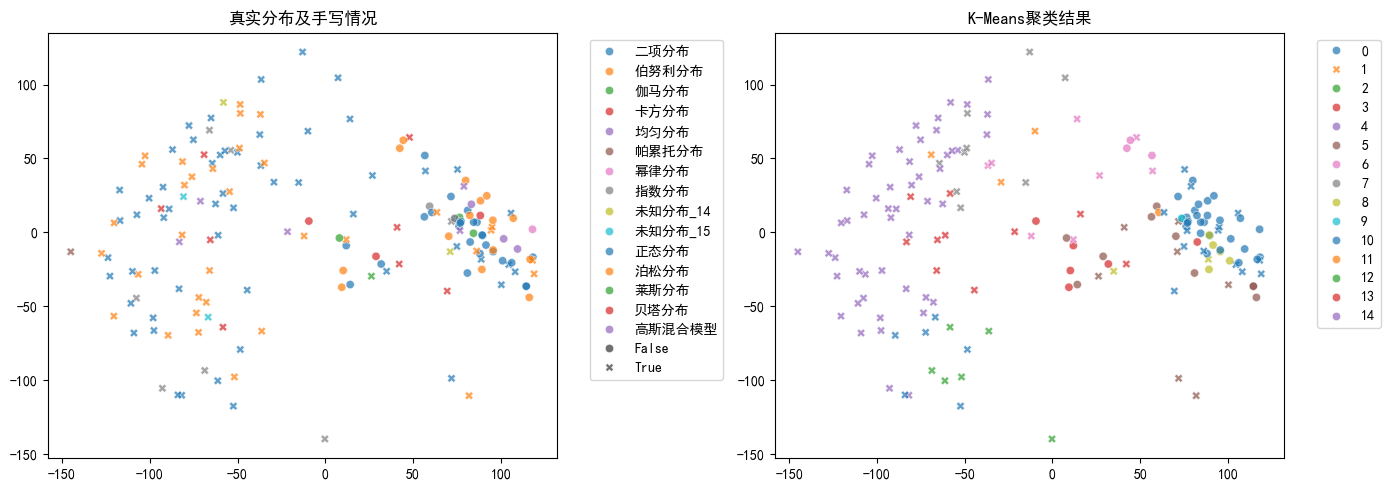

K-Means聚类各类别中手写/非手写分布：
{0: {'手写': np.int64(14), '非手写': np.int64(27)}, 1: {'手写': np.int64(2), '非手写': np.int64(0)}, 2: {'手写': np.int64(5), '非手写': np.int64(0)}, 3: {'手写': np.int64(9), '非手写': np.int64(2)}, 4: {'手写': np.int64(28), '非手写': np.int64(0)}, 5: {'手写': np.int64(7), '非手写': np.int64(10)}, 6: {'手写': np.int64(8), '非手写': np.int64(3)}, 7: {'手写': np.int64(9), '非手写': np.int64(0)}, 8: {'手写': np.int64(2), '非手写': np.int64(5)}, 9: {'手写': np.int64(0), '非手写': np.int64(1)}, 10: {'手写': np.int64(6), '非手写': np.int64(0)}, 11: {'手写': np.int64(1), '非手写': np.int64(1)}, 12: {'手写': np.int64(1), '非手写': np.int64(0)}, 13: {'手写': np.int64(1), '非手写': np.int64(4)}, 14: {'手写': np.int64(22), '非手写': np.int64(0)}}
层次聚类各类别中手写/非手写分布：
{0: {'手写': np.int64(4), '非手写': np.int64(6)}, 1: {'手写': np.int64(7), '非手写': np.int64(0)}, 2: {'手写': np.int64(1), '非手写': np.int64(5)}, 3: {'手写': np.int64(28), '非手写': np.int64(0)}, 4: {'手写': np.int64(2), '非手写': np.int64(5)}, 5: {'手写': np.int64(7), '非手写': np.int64(14)}, 6: {'手写': np.int64(17

In [8]:
# ==================== 第四部分：聚类分析任务 ====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 聚类与评价
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import normalized_mutual_info_score, accuracy_score, confusion_matrix
from scipy.optimize import linear_sum_assignment

# 输出路径（按你自己的输出路径调整）
output_dir = Path("../outputs/part4")
output_dir.mkdir(parents=True, exist_ok=True)

# -------- 1. 加载特征数据（举例,按你课程前面处理的数据路径、格式） --------
# 请确保 features.npy、labels.npy、handwritten.npy 等已存好
features = np.load('../outputs/part2/combined_features.npy')
labels = np.load('../outputs/part2/labels.npy')
handwritten = np.load('../outputs/part2/handwritten.npy')

# 方便分析label，进行编码
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
label_names = label_encoder.classes_

# 标准化
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# -------- 2. 聚类（KMeans + Hierarchical） --------
n_clusters = len(np.unique(labels_encoded))

print(f"类别数: {n_clusters}, 标签: {list(label_names)}")

# (1) K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(features_scaled)

# (2) 层次聚类
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
agg_labels = agg.fit_predict(features_scaled)

# -------- 3. 评价NMI/ACC --------
def clustering_accuracy(y_true, y_pred):
    # 用最优分配解算ACC
    cm = confusion_matrix(y_true, y_pred)
    # 匈牙利算法找到最佳标签对应关系
    row_ind, col_ind = linear_sum_assignment(-cm)
    acc = cm[row_ind, col_ind].sum() / y_true.size
    return acc

def print_eval(name, y_pred):
    nmi = normalized_mutual_info_score(labels_encoded, y_pred)
    acc = clustering_accuracy(labels_encoded, y_pred)
    print(f"{name}:  NMI={nmi:.4f}, ACC={acc:.4f}")
    return nmi, acc

nmi_kmeans, acc_kmeans = print_eval("K-Means", kmeans_labels)
nmi_agg, acc_agg = print_eval("层次聚类", agg_labels)

# -------- 4. 可视化降维聚类（PCA可选） --------
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(features_scaled)

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, style=handwritten, palette='tab10', alpha=0.7)
plt.title('真实分布及手写情况')
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")

plt.subplot(1,2,2)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_labels, style=handwritten, palette='tab10', alpha=0.7)
plt.title('K-Means聚类结果')
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()
plt.savefig(output_dir/"clustering_pca_vis.png")
plt.show()

# -------- 5. 手写与否对聚类的影响分析 --------
import collections
def count_by_handwriting(cluster_labels, handwritten, n_cluster):
    d = {}
    for c in range(n_cluster):
        indices = (cluster_labels==c)
        cnt_hand = np.sum(handwritten[indices]==1)
        cnt_non = np.sum(handwritten[indices]==0)
        d[c] = {'手写': cnt_hand, '非手写': cnt_non}
    return d

print('K-Means聚类各类别中手写/非手写分布：')
print(count_by_handwriting(kmeans_labels, handwritten, n_clusters))
print('层次聚类各类别中手写/非手写分布：')
print(count_by_handwriting(agg_labels, handwritten, n_clusters))

# -------- 6. 保存聚类结果 --------
np.save(output_dir/'kmeans_labels.npy', kmeans_labels)
np.save(output_dir/'agg_labels.npy', agg_labels)
pd.DataFrame({
    "真实分布": labels,
    "手写": handwritten,
    "KMeans聚类标签": kmeans_labels,
    "Agglomerative聚类标签": agg_labels
}).to_csv(output_dir / "clustering_results.csv", index=False)

print("聚类标签和可视化已保存！")
